# 2. Mathematics essentials: linear algebra, calculus, probability, statistics and information theory

Machine learning is applied mathematics, and four branches of it appear on almost every
page of this course. **Linear algebra** describes the data (a matrix $\mathbf{X}$) and the
models (linear maps, projections, decompositions). **Calculus** is how models are fitted:
nearly every algorithm from linear regression to transformers is trained by following a
gradient downhill. **Probability and statistics** say what the data-generating process is,
what "the best estimate" means, and how uncertain we should be about it. **Information
theory** supplies the loss functions (cross-entropy) and the splitting criteria of decision
trees.

This notebook covers exactly the mathematics the later notebooks use — no more — and it
teaches every idea *by computing it*: every definition is followed by a few lines of NumPy
that verify it, every theorem by a simulation that shows it at work. If you have studied
this before, treat it as a refresher with a computational twist. Notebooks 6 (least
squares), 7 (logistic regression), 9 (decision trees), 13 (mixtures and EM), 14 (PCA) and
15 (backpropagation) each pick up one thread from here and develop it in depth.

**Prerequisites:** notebook 1 (NumPy: shapes, broadcasting, `np.linalg`, `default_rng`).

## Learning objectives

After working through this notebook you will be able to

- compute and interpret norms, dot products, cosine similarity, projections, matrix rank and inverses, and explain matrices as linear maps;
- use the eigen-decomposition of symmetric matrices and the singular value decomposition, including the geometry of the SVD and the best low-rank approximation of a matrix;
- explain why covariance matrices are positive semi-definite and what that means for quadratic forms;
- derive gradients with the chain rule (including $\nabla_\mathbf{w}\|\mathbf{X}\mathbf{w}-\mathbf{y}\|^2$), check them numerically, and implement gradient descent, understanding the roles of the learning rate, conditioning and convexity;
- work with random variables, expectations, common distributions, joint/marginal/conditional probabilities and Bayes' theorem, and explain the law of large numbers and the central limit theorem;
- define estimators and their bias and variance, derive maximum-likelihood estimates, and show that least squares and cross-entropy are maximum likelihood in disguise (and ridge regression is MAP);
- compute confidence intervals analytically and by the bootstrap, and run — and criticise — a paired $t$-test on model scores;
- compute entropy, cross-entropy, KL divergence and mutual information, and relate them to loss functions and to information gain.

## Setup

In [1]:
import numpy as np                 # arrays, linear algebra (np.linalg) and random numbers
import pandas as pd                # DataFrames, used for the probability tables in section 3.3
import matplotlib.pyplot as plt    # plotting
import seaborn as sns              # statistical plots on top of matplotlib (not used in this notebook)
# SciPy: stats = probability distributions and statistical tests, optimize = numerical minimisation,
# integrate = numerical integration
from scipy import stats, optimize, integrate

# course helpers: plot style, colour list, and the loader for the cleaned customer-churn table
from course_utils import set_style, PALETTE, load_churn

RANDOM_STATE = 42                          # one fixed seed so every run gives the same random numbers
rng = np.random.default_rng(RANDOM_STATE)  # the seeded random-number generator used throughout
set_style()

## 1. Linear algebra

### 1.1 Vectors, norms, dot products and cosine similarity

A **vector** $\mathbf{x} \in \mathbb{R}^d$ is an ordered list of $d$ numbers — in this
course, usually one data point: a customer described by $d$ features, or a document by
$d$ word counts. A **norm** measures the length of a vector; the three we use are

$$
\|\mathbf{x}\|_2 = \sqrt{\textstyle\sum_j x_j^2}, \qquad
\|\mathbf{x}\|_1 = \textstyle\sum_j |x_j|, \qquad
\|\mathbf{x}\|_\infty = \max_j |x_j| .
$$

The Euclidean norm $\|\cdot\|_2$ is ordinary length; the Manhattan norm $\|\cdot\|_1$ is the
distance you walk on a grid of streets. Their unit balls (the sets $\{\mathbf{x} :
\|\mathbf{x}\| \le 1\}$) look different, and that difference is the whole story of ridge
versus lasso regularisation in notebook 6: the $\ell_1$ ball has corners on the axes,
which is why $\ell_1$ penalties produce sparse solutions.

The **dot product** (inner product) $\mathbf{x}^\top \mathbf{y} = \sum_j x_j y_j$ links
lengths and angles:

$$
\mathbf{x}^\top \mathbf{y} \;=\; \|\mathbf{x}\|_2 \,\|\mathbf{y}\|_2 \cos\theta ,
\qquad\text{so}\qquad
\cos\theta \;=\; \frac{\mathbf{x}^\top \mathbf{y}}{\|\mathbf{x}\|_2 \|\mathbf{y}\|_2}
$$

is the **cosine similarity** — $1$ for parallel vectors, $0$ for orthogonal
(perpendicular) ones, $-1$ for opposite ones. It ignores the lengths of the vectors, which
is exactly what one wants when comparing documents of different lengths (notebook 15) or embeddings. Every linear model computes $\mathbf{w}^\top\mathbf{x}$: a
prediction is a dot product between the weights and the features.

||x||_2 = 5.0, ||x||_1 = 7.0, ||x||_inf = 4.0
x.y = 0.0  -> cosine +0.00 (orthogonal)
x.z = 50.0  -> cosine +1.00 (parallel: z = 2x, different length, same direction)


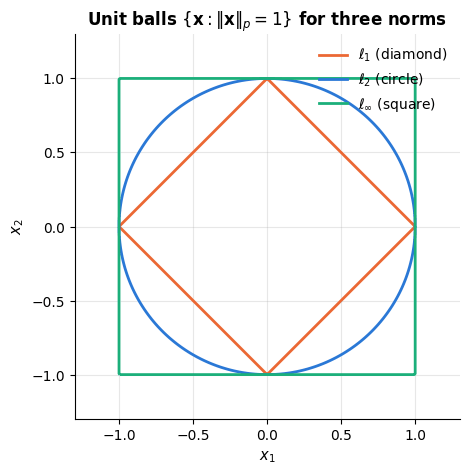

In [2]:
x = np.array([3.0, 4.0])
y = np.array([4.0, -3.0])
z = np.array([6.0, 8.0])

def cosine_similarity(a, b):
    """Cosine of the angle between vectors a and b: a.b / (||a|| ||b||), a number between -1 and 1."""
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b))    # @ between two 1-D arrays is the dot product

# np.linalg.norm(v, ord): the default ord is the Euclidean (l2) norm, 1 the l1 norm, np.inf the largest |entry|
print(f"||x||_2 = {np.linalg.norm(x):.1f}, ||x||_1 = {np.linalg.norm(x, 1):.1f}, ||x||_inf = {np.linalg.norm(x, np.inf):.1f}")
# the format spec :+.2f always prints the sign (+ or -) and 2 decimals
print(f"x.y = {x @ y:.1f}  -> cosine {cosine_similarity(x, y):+.2f} (orthogonal)")
print(f"x.z = {x @ z:.1f}  -> cosine {cosine_similarity(x, z):+.2f} (parallel: z = 2x, different length, same direction)")

# unit balls of the three norms
grid = np.linspace(-1.3, 1.3, 400)          # 400 evenly spaced values from -1.3 to 1.3
# np.meshgrid turns two 1-D grids into two (400, 400) arrays: gx holds the x and gy the y coordinate of every point
gx, gy = np.meshgrid(grid, grid)
fig, ax = plt.subplots(figsize=(5, 5))
for p, name, color in [(1, "$\\ell_1$ (diamond)", PALETTE[1]), (2, "$\\ell_2$ (circle)", PALETTE[0]), (np.inf, "$\\ell_\\infty$ (square)", PALETTE[2])]:
    # stack to (400, 400, 2), one 2-D point per grid position; the norm along axis=-1 gives (400, 400)
    norm = np.linalg.norm(np.stack([gx, gy], axis=-1), ord=p, axis=-1)
    ax.contour(gx, gy, norm, levels=[1.0], colors=[color], linewidths=2)   # draw only the curve where norm == 1
    ax.plot([], [], color=color, lw=2, label=name)     # an empty line, only to get a legend entry for the contour
ax.set_aspect("equal")                      # one unit is equally long on both axes, so a circle looks round
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Unit balls $\\{\\mathbf{x}: \\|\\mathbf{x}\\|_p = 1\\}$ for three norms")
ax.legend(loc="upper right")
plt.show()

### 1.2 Matrices as linear maps

A matrix $\mathbf{A} \in \mathbb{R}^{m \times n}$ is a table of numbers, but the useful way
to think of it is as a **function** $\mathbf{x} \mapsto \mathbf{A}\mathbf{x}$ from
$\mathbb{R}^n$ to $\mathbb{R}^m$ that is *linear*: $\mathbf{A}(\alpha\mathbf{x} + \beta\mathbf{y})
= \alpha\mathbf{A}\mathbf{x} + \beta\mathbf{A}\mathbf{y}$. The columns of $\mathbf{A}$ are the
images of the basis vectors, and $\mathbf{A}\mathbf{x}$ is a linear combination of those
columns with the entries of $\mathbf{x}$ as weights. In two dimensions every linear map is
some combination of rotation, scaling and shear, and some maps *lose* a dimension:

- The **rank** of $\mathbf{A}$ is the dimension of its image (the column space), i.e. the
  number of linearly independent columns. A rank-deficient map squashes the plane onto a
  line (or a point).
- The **determinant** of a square matrix is the factor by which it scales area (volume);
  $\det \mathbf{A} = 0$ exactly when the map collapses a dimension, i.e. when $\mathbf{A}$
  has no **inverse** $\mathbf{A}^{-1}$ (the map that undoes it).
- The **matrix product** $\mathbf{A}\mathbf{B}$ is the composition of the maps ("first
  $\mathbf{B}$, then $\mathbf{A}$"), which is why it is associative but *not* commutative,
  and why $(\mathbf{A}\mathbf{B})^\top = \mathbf{B}^\top\mathbf{A}^\top$. Computing it costs
  $O(mnp)$ operations for an $m \times n$ times $n \times p$ product — $O(n^3)$ for square
  matrices — which is why "just multiply the matrices" can be the most expensive step of an
  algorithm.

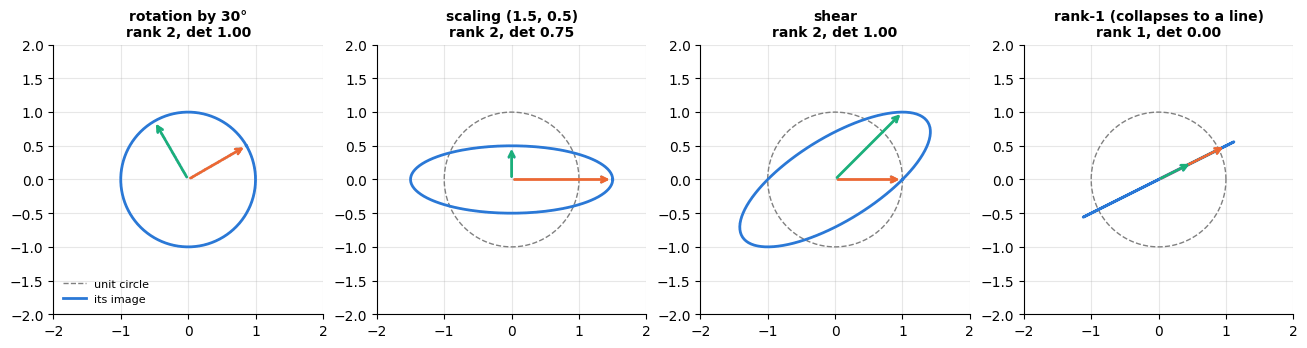

A @ B == B @ A ? False    (matrix products do not commute)
(A @ B).T == B.T @ A.T ? True
A @ inv(A) == I ? True | rotation inverse = transpose: True


In [3]:
theta = np.deg2rad(30)                      # NumPy's trigonometric functions expect radians
maps = {
    "rotation by 30°": np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]]),
    "scaling (1.5, 0.5)": np.array([[1.5, 0.0], [0.0, 0.5]]),
    "shear": np.array([[1.0, 1.0], [0.0, 1.0]]),
    "rank-1 (collapses to a line)": np.array([[1.0, 0.5], [0.5, 0.25]]),   # second row = 0.5 x first row
}
t = np.linspace(0, 2 * np.pi, 200)
circle = np.stack([np.cos(t), np.sin(t)])                    # shape (2, 200): one point per column
e1, e2 = np.array([1.0, 0.0]), np.array([0.0, 1.0])         # the two basis vectors

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, A) in zip(axes, maps.items()):     # zip pairs each panel with one (name, matrix) entry
    image = A @ circle                            # (2, 2) @ (2, 200) -> (2, 200): every circle point mapped by A
    ax.plot(circle[0], circle[1], color="gray", ls="--", lw=1, label="unit circle")
    ax.plot(image[0], image[1], color=PALETTE[0], lw=2, label="its image")
    for vec, color in [(e1, PALETTE[1]), (e2, PALETTE[2])]:
        # annotate("", xy=end, xytext=start, arrowprops=...) draws just an arrow; A @ e1 is the first column of A
        ax.annotate("", xy=A @ vec, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=color, lw=2))
    ax.set_aspect("equal")
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    # matrix_rank counts the linearly independent columns; det is the factor by which A scales area
    ax.set_title(f"{name}\nrank {np.linalg.matrix_rank(A)}, det {np.linalg.det(A):.2f}", fontsize=10)
axes[0].legend(loc="lower left", fontsize=8)
plt.show()

A, B = maps["rotation by 30°"], maps["shear"]
# np.allclose(a, b): True when all entries agree up to tiny floating-point differences
print("A @ B == B @ A ?", np.allclose(A @ B, B @ A), "   (matrix products do not commute)")
print("(A @ B).T == B.T @ A.T ?", np.allclose((A @ B).T, B.T @ A.T))
# np.linalg.inv computes the inverse matrix; np.eye(2) is the 2 x 2 identity
print("A @ inv(A) == I ?", np.allclose(A @ np.linalg.inv(A), np.eye(2)), "| rotation inverse = transpose:", np.allclose(np.linalg.inv(A), A.T))

The orange and green arrows are the images of the basis vectors — the columns of each
matrix. The rank-1 matrix sends the whole circle onto a line segment: two different inputs
can have the same output, so the map cannot be undone (`np.linalg.inv` would raise
`LinAlgError`). Rotations are **orthogonal** matrices ($\mathbf{Q}^\top\mathbf{Q} =
\mathbf{I}$, so $\mathbf{Q}^{-1} = \mathbf{Q}^\top$): they preserve lengths and angles, and
they will reappear as the $\mathbf{U}$ and $\mathbf{V}$ of the SVD.

### 1.3 Projections and orthogonality

Two vectors are **orthogonal** if $\mathbf{x}^\top\mathbf{y} = 0$. The **projection** of
$\mathbf{b}$ onto the line spanned by $\mathbf{a}$ is the point on that line closest to
$\mathbf{b}$:

$$
\mathbf{p} \;=\; \frac{\mathbf{a}^\top\mathbf{b}}{\mathbf{a}^\top\mathbf{a}}\,\mathbf{a},
\qquad\text{and the residual } \mathbf{b} - \mathbf{p} \text{ is orthogonal to } \mathbf{a}.
$$

More generally, the projection of $\mathbf{b}$ onto the **column space** of a matrix
$\mathbf{A} \in \mathbb{R}^{n \times d}$ (all vectors of the form $\mathbf{A}\mathbf{w}$) is
$\mathbf{p} = \mathbf{A}\hat{\mathbf{w}}$ where $\hat{\mathbf{w}}$ is chosen so that the
residual is orthogonal to every column: $\mathbf{A}^\top(\mathbf{b} - \mathbf{A}\hat{\mathbf{w}})
= \mathbf{0}$, i.e.

$$
\mathbf{A}^\top\mathbf{A}\,\hat{\mathbf{w}} = \mathbf{A}^\top\mathbf{b}
\qquad\Longrightarrow\qquad
\mathbf{p} = \mathbf{P}\mathbf{b}, \quad \mathbf{P} = \mathbf{A}(\mathbf{A}^\top\mathbf{A})^{-1}\mathbf{A}^\top .
$$

These are the **normal equations** of least squares (notebooks 1 and 6): fitting a linear
model *is* projecting the target vector $\mathbf{y}$ onto the column space of the design
matrix $\mathbf{X}$. The projection matrix $\mathbf{P}$ is symmetric and idempotent
($\mathbf{P}^2 = \mathbf{P}$ — projecting twice changes nothing).

projection of b onto the line of a: [2.588 0.647] | residual orthogonal to a: True
P symmetric: True | P idempotent: True | rank of P: 2
P b == A w_hat: True | A^T (b - P b) == 0: True
least squares via lstsq gives the same w_hat: True


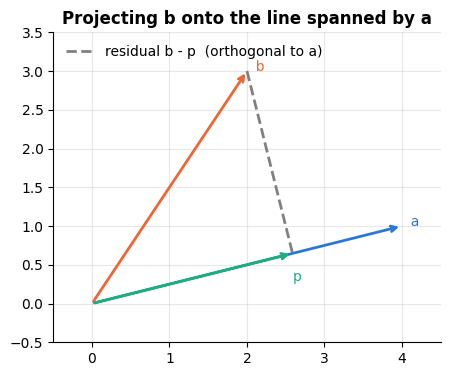

In [4]:
a = np.array([4.0, 1.0])
b = np.array([2.0, 3.0])
p = (a @ b) / (a @ a) * a                 # projection of b onto the line through a: (a.b / a.a) a
# np.isclose(x, 0) is the single-number version of allclose: True if x is 0 up to round-off
print("projection of b onto the line of a:", p.round(3), "| residual orthogonal to a:", np.isclose(a @ (b - p), 0))

A = rng.normal(size=(6, 2))                 # column space = a plane in R^6
b6 = rng.normal(size=6)
# np.linalg.solve(M, B) returns X with M X = B; with B = A.T (2, 6) the result is (A^T A)^{-1} A^T, shape (2, 6)
P = A @ np.linalg.solve(A.T @ A, A.T)      # A (A^T A)^{-1} A^T without forming the inverse explicitly
w_hat = np.linalg.solve(A.T @ A, A.T @ b6)  # normal equations
print("P symmetric:", np.allclose(P, P.T), "| P idempotent:", np.allclose(P @ P, P), "| rank of P:", np.linalg.matrix_rank(P))
print("P b == A w_hat:", np.allclose(P @ b6, A @ w_hat), "| A^T (b - P b) == 0:", np.allclose(A.T @ (b6 - P @ b6), 0))
# np.linalg.lstsq solves the least-squares problem directly; [0] picks the solution from the tuple it returns
print("least squares via lstsq gives the same w_hat:", np.allclose(np.linalg.lstsq(A, b6, rcond=None)[0], w_hat))

fig, ax = plt.subplots(figsize=(5, 4.2))
# three arrows from the origin: a, b and the projection p
ax.annotate("", xy=a, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=PALETTE[0], lw=2))
ax.annotate("", xy=b, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=PALETTE[1], lw=2))
ax.annotate("", xy=p, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=PALETTE[2], lw=2))
ax.plot([b[0], p[0]], [b[1], p[1]], color="gray", ls="--", label="residual b - p  (orthogonal to a)")
ax.text(*a, "  a", color=PALETTE[0])      # *a unpacks the array into the two arguments x and y
ax.text(*b, "  b", color=PALETTE[1])
ax.text(p[0], p[1] - 0.35, "p", color=PALETTE[2])
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.5, 3.5)
ax.set_aspect("equal")
ax.set_title("Projecting b onto the line spanned by a")
ax.legend(loc="upper left")
plt.show()

### 1.4 Eigen-decomposition of symmetric matrices

A vector $\mathbf{q}$ is an **eigenvector** of a square matrix $\mathbf{A}$ with
**eigenvalue** $\lambda$ if $\mathbf{A}\mathbf{q} = \lambda\mathbf{q}$: the map does not
rotate $\mathbf{q}$, it only stretches it by $\lambda$. For a **symmetric** matrix
($\mathbf{A} = \mathbf{A}^\top$) the *spectral theorem* says that there are $n$ real
eigenvalues with mutually orthogonal eigenvectors, so

$$
\mathbf{A} \;=\; \mathbf{Q}\,\boldsymbol{\Lambda}\,\mathbf{Q}^\top
\;=\; \sum_{i=1}^n \lambda_i\,\mathbf{q}_i\mathbf{q}_i^\top,
\qquad \mathbf{Q}^\top\mathbf{Q} = \mathbf{I}, \quad \boldsymbol{\Lambda} = \operatorname{diag}(\lambda_1, \dots, \lambda_n).
$$

Symmetric matrices are the ones that matter in this course — covariance matrices, Gram
matrices $\mathbf{X}^\top\mathbf{X}$, kernel matrices (notebook 11), Hessians — and for
them `np.linalg.eigh` is the right function (faster than `eig`, and it guarantees real,
sorted output). The most important example: the **covariance matrix** of a data set,
$\boldsymbol{\Sigma} = \frac{1}{n-1}\mathbf{X}_c^\top\mathbf{X}_c$ where $\mathbf{X}_c$ is
$\mathbf{X}$ with column means removed. Its eigenvectors are the directions along which the
data vary independently — the *principal axes* of the point cloud — and its eigenvalues are
the variances along those axes. That single fact is principal component analysis
(notebook 14).

sample covariance:
 [[3.073 1.066]
 [1.066 0.845]]
eigenvalues: [0.417 3.501] | eigenvectors orthonormal: True
Q diag(lam) Q^T reconstructs Sigma: True
trace = sum of eigenvalues = total variance: 3.918 3.918
variance of the data projected on the top eigenvector: 3.501 = largest eigenvalue


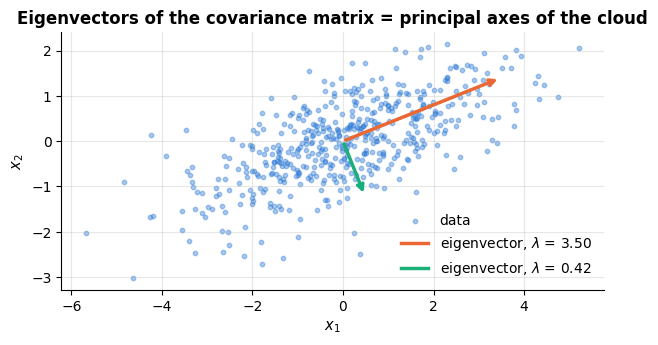

In [5]:
Sigma_true = np.array([[3.0, 1.2], [1.2, 1.0]])
# 500 draws from a 2-D Gaussian with mean (0, 0) and covariance Sigma_true -> shape (500, 2)
X = rng.multivariate_normal(mean=[0, 0], cov=Sigma_true, size=500)
# rowvar=False tells np.cov that the columns are the variables and the rows the observations
Sigma = np.cov(X, rowvar=False)                      # (2, 2) sample covariance
lam, Q = np.linalg.eigh(Sigma)                       # ascending eigenvalues, orthonormal eigenvectors as columns
print("sample covariance:\n", Sigma.round(3))
print("eigenvalues:", lam.round(3), "| eigenvectors orthonormal:", np.allclose(Q.T @ Q, np.eye(2)))
print("Q diag(lam) Q^T reconstructs Sigma:", np.allclose(Q @ np.diag(lam) @ Q.T, Sigma))   # np.diag(v): v on a diagonal
# np.trace is the sum of the diagonal entries
print("trace = sum of eigenvalues = total variance:", np.trace(Sigma).round(3), lam.sum().round(3))
# Q[:, 1] is the eigenvector of the largest eigenvalue (eigh sorts ascending); X @ it projects every point onto it
print("variance of the data projected on the top eigenvector:", (X @ Q[:, 1]).var(ddof=1).round(3), "= largest eigenvalue")

# Q[0] is the first row (the x1 components); np.sign gives +-1 per column, and multiplying flips the columns with x1 < 0
Q = Q * np.sign(Q[0])                                # eigenvector signs are arbitrary: make them point to positive x1
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.scatter(X[:, 0], X[:, 1], s=10, alpha=0.4, label="data")
for i, color in zip([1, 0], [PALETTE[1], PALETTE[2]]):   # largest eigenvalue first
    v = Q[:, i] * 2 * np.sqrt(lam[i])                 # length = 2 standard deviations along that axis
    ax.annotate("", xy=v, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=color, lw=2.5))
    ax.plot([], [], color=color, lw=2.5, label=f"eigenvector, $\\lambda$ = {lam[i]:.2f}")   # legend entry only
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Eigenvectors of the covariance matrix = principal axes of the cloud")
ax.legend(loc="lower right")
plt.show()

### 1.5 The singular value decomposition

The eigen-decomposition needs a square symmetric matrix. Every matrix, of any shape, has a
**singular value decomposition** (SVD):

$$
\mathbf{A} \;=\; \mathbf{U}\,\boldsymbol{\Sigma}\,\mathbf{V}^\top,
\qquad \mathbf{U} \in \mathbb{R}^{m \times r},\ \boldsymbol{\Sigma} = \operatorname{diag}(\sigma_1 \ge \dots \ge \sigma_r > 0),\ \mathbf{V} \in \mathbb{R}^{n \times r},
$$

with orthonormal columns in $\mathbf{U}$ and $\mathbf{V}$ and $r = \operatorname{rank}\mathbf{A}$
(the "thin" SVD that `np.linalg.svd(A, full_matrices=False)` returns). Geometrically, every
linear map is *a rotation ($\mathbf{V}^\top$), then a scaling by the singular values, then
another rotation ($\mathbf{U}$)*: the unit circle is always mapped to an ellipse whose
semi-axes have lengths $\sigma_i$. The SVD and the eigen-decomposition are related by
$\mathbf{A}^\top\mathbf{A} = \mathbf{V}\boldsymbol{\Sigma}^2\mathbf{V}^\top$ — the right
singular vectors are the eigenvectors of the Gram matrix and $\sigma_i^2$ its eigenvalues,
which is why PCA can be computed either way (notebook 14).

The property that makes the SVD indispensable in machine learning is the **Eckart–Young
theorem** (Eckart & Young, 1936): the best rank-$k$ approximation of $\mathbf{A}$, in the
sense of the Frobenius norm (and the spectral norm), is obtained by keeping the $k$ largest
singular values,

$$
\mathbf{A}_k = \sum_{i=1}^k \sigma_i\,\mathbf{u}_i\mathbf{v}_i^\top,
\qquad
\|\mathbf{A} - \mathbf{A}_k\|_F = \sqrt{\textstyle\sum_{i>k}\sigma_i^2}.
$$

An image is a matrix, so we can *see* this. We use one of the two sample photographs
bundled with scikit-learn (converted to greyscale, $427 \times 640$ pixels).

image shape: (427, 640) | number of singular values: 427 | largest five: [83442. 15393.  9760.  5762.  4909.]


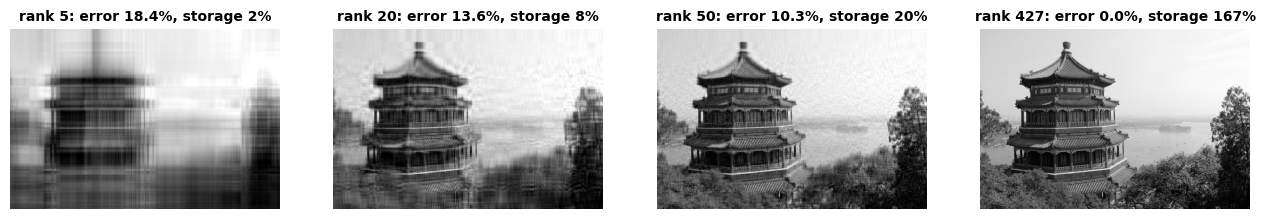

In [6]:
from sklearn.datasets import load_sample_images     # the two example photos that ship with scikit-learn

# .images is a list of two RGB photos, each (427, 640, 3) with values 0-255; [0] takes the first one
image = load_sample_images().images[0].mean(axis=2)        # RGB -> greyscale, shape (427, 640)
# thin SVD: U (427, 427), s (427,) sorted descending, Vt (427, 640)
U, s, Vt = np.linalg.svd(image, full_matrices=False)
print("image shape:", image.shape, "| number of singular values:", len(s), "| largest five:", s[:5].round(0))

ranks = [5, 20, 50, len(s)]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
for ax, k in zip(axes, ranks):
    # U[:, :k] * s[:k] scales column i of U by s_i (broadcasting), like U_k @ diag(s_k); @ Vt[:k] then gives (427, 640)
    approx = (U[:, :k] * s[:k]) @ Vt[:k]                      # sum of the k leading rank-1 terms
    rel_err = np.linalg.norm(image - approx) / np.linalg.norm(image)   # for a matrix, norm() is the Frobenius norm
    # numbers to store: k columns of U (427 each) + k rows of Vt (640 each) + k singular values, as a share of the pixels
    storage = k * (image.shape[0] + image.shape[1] + 1) / image.size
    ax.imshow(approx, cmap="gray", vmin=0, vmax=255)          # the same 0-255 grey scale in every panel
    ax.set_title(f"rank {k}: error {rel_err:.1%}, storage {storage:.0%}", fontsize=10)
    ax.axis("off")
plt.show()

Fifty numbers per row and column (a fifth of the storage) give a recognisable picture,
because the singular values decay fast — most of the "energy" $\sum\sigma_i^2$ is in the
first few components. That decay is what makes dimensionality reduction (notebook 14) and
low-rank recommender models (notebook 14, matrix factorisation) work, and it is worth
looking at directly:

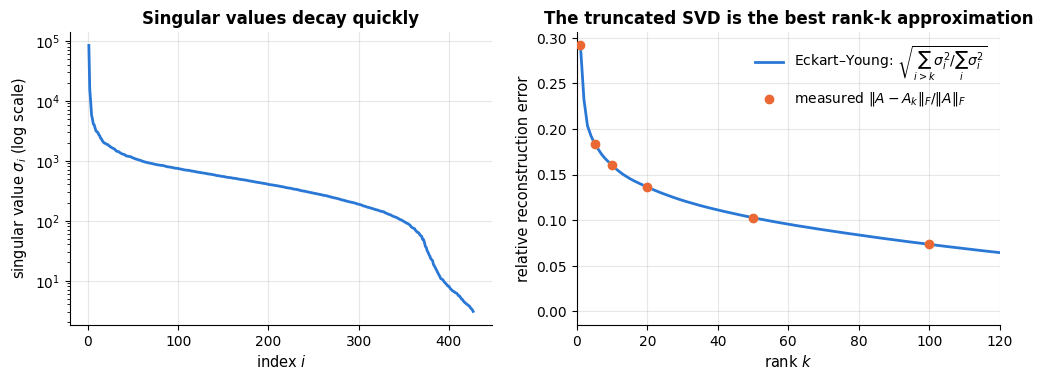

components needed for 99% / 99.9% of the energy sum(sigma_i^2): 54 / 216 of 427


In [7]:
# np.cumsum gives running totals, so energy[k - 1] is the share of sum(sigma_i^2) held by the first k values
energy = np.cumsum(s ** 2) / np.sum(s ** 2)
ks = np.arange(1, len(s) + 1)                                  # ranks 1, 2, ..., 427
predicted_err = np.sqrt(1 - energy)                            # Eckart-Young: ||A - A_k||_F / ||A||_F
# the actual relative error of the rank-k approximation, measured for six values of k
measured_err = [np.linalg.norm(image - (U[:, :k] * s[:k]) @ Vt[:k]) / np.linalg.norm(image) for k in [1, 5, 10, 20, 50, 100]]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].semilogy(ks, s, lw=2)                 # semilogy: a line plot with a logarithmic y-axis
axes[0].set_xlabel("index $i$")
axes[0].set_ylabel("singular value $\\sigma_i$ (log scale)")
axes[0].set_title("Singular values decay quickly")
axes[1].plot(ks, predicted_err, lw=2, label="Eckart–Young: $\\sqrt{\\sum_{i>k}\\sigma_i^2 / \\sum_i \\sigma_i^2}$")
# zorder=3 draws the dots on top of the line
axes[1].scatter([1, 5, 10, 20, 50, 100], measured_err, color=PALETTE[1], zorder=3, label="measured $\\|A - A_k\\|_F / \\|A\\|_F$")
axes[1].set_xlim(0, 120)
axes[1].set_xlabel("rank $k$")
axes[1].set_ylabel("relative reconstruction error")
axes[1].set_title("The truncated SVD is the best rank-k approximation")
axes[1].legend()
plt.show()
# np.searchsorted(energy, 0.99) is the first index where the (increasing) energy reaches 0.99; + 1 turns it into a count
print(f"components needed for 99% / 99.9% of the energy sum(sigma_i^2): {np.searchsorted(energy, 0.99) + 1} / {np.searchsorted(energy, 0.999) + 1} of {len(s)}")

### 1.6 Positive (semi-)definite matrices and the covariance matrix

A symmetric matrix $\mathbf{A}$ is **positive semi-definite** (PSD, written
$\mathbf{A} \succeq 0$) if the quadratic form $\mathbf{x}^\top\mathbf{A}\mathbf{x} \ge 0$
for every $\mathbf{x}$, and **positive definite** (PD, $\mathbf{A} \succ 0$) if the
inequality is strict for $\mathbf{x} \ne \mathbf{0}$. Equivalently: all eigenvalues are
$\ge 0$ (resp. $> 0$). Three reasons to care:

1. **Every covariance matrix is PSD.** With $\mathbf{X}_c$ the centred data,
   $\mathbf{x}^\top\boldsymbol{\Sigma}\mathbf{x} = \frac{1}{n-1}\mathbf{x}^\top\mathbf{X}_c^\top\mathbf{X}_c\mathbf{x}
   = \frac{1}{n-1}\|\mathbf{X}_c\mathbf{x}\|_2^2 \ge 0$ — it is the variance of the data
   projected onto direction $\mathbf{x}$, and variances cannot be negative. The same
   argument shows that every Gram matrix $\mathbf{X}^\top\mathbf{X}$ and every kernel matrix
   is PSD.
2. **PD matrices define bowl-shaped functions.** $f(\mathbf{w}) = \frac{1}{2}\mathbf{w}^\top\mathbf{A}\mathbf{w}$
   has ellipsoidal contours with a unique minimum when $\mathbf{A} \succ 0$, and a saddle
   when $\mathbf{A}$ has eigenvalues of both signs. Since the Hessian of the least-squares
   loss is $2\mathbf{X}^\top\mathbf{X} \succeq 0$, least squares is convex (section 2.6).
3. **Regularisation makes PSD matrices PD.** $\mathbf{X}^\top\mathbf{X}$ can be singular
   (collinear features); adding $\lambda\mathbf{I}$ shifts every eigenvalue up by $\lambda$,
   which is why ridge regression (notebook 6) always has a unique solution.

min of x^T Sigma x over 10 000 random directions: 0.000  (never negative)
eigenvalues of Sigma: [0.417 3.501]
eigenvalues of the indefinite matrix: [-1.  1.]
eigenvalues of a singular Gram matrix: [0. 5.] -> after adding 0.5 I: [0.5 5.5]


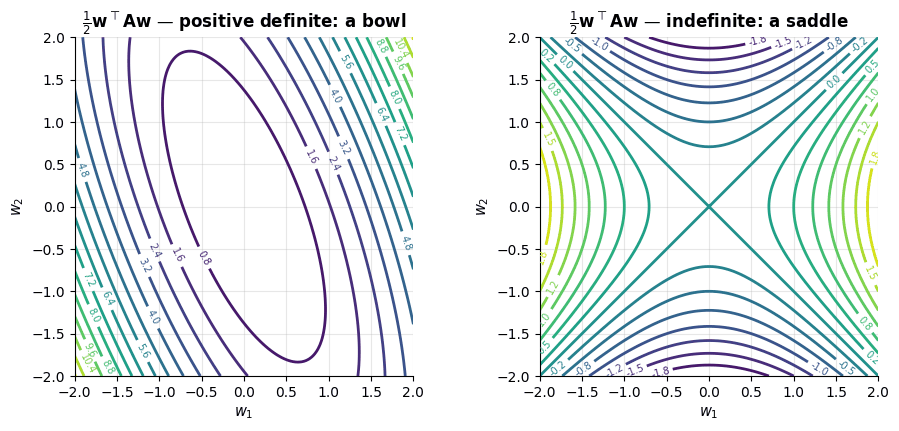

In [8]:
X_c = X - X.mean(axis=0)                  # centre the data: subtract each column's mean, (500, 2) - (2,)
Sigma = X_c.T @ X_c / (len(X) - 1)        # the covariance formula by hand (the same as np.cov above)
directions = rng.normal(size=(10000, 2))  # 10 000 random 2-D vectors
# np.einsum writes a sum over indices: each letter labels an axis, and letters missing after "->" are summed over;
# here quad[i] = sum over j, k of directions[i, j] * Sigma[j, k] * directions[i, k]
quad = np.einsum("ij,jk,ik->i", directions, Sigma, directions)     # x^T Sigma x for 10 000 random x
print(f"min of x^T Sigma x over 10 000 random directions: {quad.min():.3f}  (never negative)")
# np.linalg.eigvalsh returns only the eigenvalues of a symmetric matrix, in ascending order
print("eigenvalues of Sigma:", np.linalg.eigvalsh(Sigma).round(3))
indefinite = np.array([[1.0, 0.0], [0.0, -1.0]])
print("eigenvalues of the indefinite matrix:", np.linalg.eigvalsh(indefinite))
singular_gram = np.array([[1.0, 2.0], [2.0, 4.0]])                  # X^T X for two collinear features
print("eigenvalues of a singular Gram matrix:", np.linalg.eigvalsh(singular_gram).round(3),
      "-> after adding 0.5 I:", np.linalg.eigvalsh(singular_gram + 0.5 * np.eye(2)).round(3))

w1, w2 = np.meshgrid(np.linspace(-2, 2, 200), np.linspace(-2, 2, 200))   # each (200, 200)
W = np.stack([w1, w2], axis=-1)           # (200, 200, 2): one weight vector w per grid point
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (name, M) in zip(axes, [("positive definite: a bowl", Sigma), ("indefinite: a saddle", indefinite)]):
    # "..." in einsum stands for any leading axes (here 200 x 200): w^T M w at every grid point -> (200, 200)
    f = 0.5 * np.einsum("...i,ij,...j->...", W, M, W)
    cs = ax.contour(w1, w2, f, levels=15, cmap="viridis")    # 15 contour lines of f, coloured by level
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.1f")       # write each line's value on it, with 1 decimal
    ax.set_aspect("equal")
    ax.set_xlabel("$w_1$")
    ax.set_ylabel("$w_2$")
    # in an f-string {{ and }} produce literal braces, which the LaTeX \frac{1}{2} needs
    ax.set_title(f"$\\frac{{1}}{{2}}\\mathbf{{w}}^\\top \\mathbf{{A}} \\mathbf{{w}}$ — {name}")
plt.show()

## 2. Calculus for optimisation

### 2.1 Derivatives, gradients and the chain rule

The derivative $f'(x) = \lim_{h\to 0}\frac{f(x+h) - f(x)}{h}$ is the slope of $f$ at $x$ —
the factor by which a tiny change in the input is amplified in the output. For a function
of several variables $f: \mathbb{R}^d \to \mathbb{R}$ the **gradient** collects the partial
derivatives,

$$
\nabla f(\mathbf{x}) = \Big(\frac{\partial f}{\partial x_1}, \dots, \frac{\partial f}{\partial x_d}\Big)^\top,
\qquad f(\mathbf{x} + \boldsymbol{\delta}) \approx f(\mathbf{x}) + \nabla f(\mathbf{x})^\top \boldsymbol{\delta} .
$$

The linear approximation gives the two facts optimisation lives on: the gradient points in
the direction of **steepest ascent** (the $\boldsymbol{\delta}$ of fixed length that
increases $f$ most is parallel to $\nabla f$), and at an interior minimum the gradient is
zero. For a vector-valued $\mathbf{g}: \mathbb{R}^d \to \mathbb{R}^m$ the matrix of partials
$\mathbf{J}_{ij} = \partial g_i / \partial x_j$ is the **Jacobian**; the matrix of second
derivatives of a scalar function, $\mathbf{H}_{ij} = \partial^2 f / \partial x_i \partial x_j$,
is the **Hessian** — the curvature, which decides whether a stationary point is a minimum
(all eigenvalues $> 0$), a maximum (all $< 0$) or a saddle (mixed).

The **chain rule** is how gradients of complicated functions are assembled from simple
pieces. For a composition $f(\mathbf{x}) = h(\mathbf{g}(\mathbf{x}))$,

$$
\nabla f(\mathbf{x}) = \mathbf{J}_{\mathbf{g}}(\mathbf{x})^\top\,\nabla h(\mathbf{g}(\mathbf{x})) ,
$$

i.e. multiply the Jacobians of the layers, innermost last. A neural network is a long
composition of simple layers, and *backpropagation* in neural networks is nothing but this
formula applied layer by layer, reusing intermediate results.

**Numerical gradient checking.** Any hand-derived gradient should be checked against a
finite-difference approximation. The central difference

$$
\frac{\partial f}{\partial x_i} \approx \frac{f(\mathbf{x} + \varepsilon\mathbf{e}_i) - f(\mathbf{x} - \varepsilon\mathbf{e}_i)}{2\varepsilon}
$$

has error $O(\varepsilon^2)$; with $\varepsilon \approx 10^{-5}$ in double precision it
agrees with the true gradient to about eight digits. It is far too slow to *train* with
($d+1$ evaluations of $f$ per gradient, versus one backward pass), but it is the standard
unit test for gradient code.

In [9]:
def numerical_gradient(f, x, eps=1e-5):
    """Central-difference gradient of a scalar function f at the point x (a 1-D array).

    Returns an array shaped like x whose entry i is (f(x + eps e_i) - f(x - eps e_i)) / (2 eps).
    """
    x = np.asarray(x, dtype=float)       # accept lists too, and make sure the values are floats
    grad = np.zeros_like(x)              # an array of zeros with the same shape and dtype as x
    for i in range(len(x)):
        step = np.zeros_like(x)
        step[i] = eps                    # a small step along coordinate i only
        grad[i] = (f(x + step) - f(x - step)) / (2 * eps)
    return grad

def relative_error(g_analytic, g_numeric):
    """Relative difference ||g1 - g2|| / (||g1|| + ||g2||) of two gradients: near 0 when they agree."""
    return np.linalg.norm(g_analytic - g_numeric) / (np.linalg.norm(g_analytic) + np.linalg.norm(g_numeric))

# f(x, y) = x^2 y + sin(y): grad = (2xy, x^2 + cos(y))
# lambda defines a small unnamed function; v is the point (x, y), so v[0] = x and v[1] = y
f = lambda v: v[0] ** 2 * v[1] + np.sin(v[1])
grad_f = lambda v: np.array([2 * v[0] * v[1], v[0] ** 2 + np.cos(v[1])])
point = np.array([1.5, -0.7])
print("analytic :", grad_f(point).round(6))
print("numeric  :", numerical_gradient(f, point).round(6))
# :.1e prints in scientific notation with 1 decimal
print(f"relative error: {relative_error(grad_f(point), numerical_gradient(f, point)):.1e}")

analytic : [-2.1       3.014842]
numeric  : [-2.1       3.014842]
relative error: 4.1e-12


### 2.2 The gradient of the least-squares loss, derived

The loss of linear regression is $\mathcal{L}(\mathbf{w}) = \|\mathbf{X}\mathbf{w} -
\mathbf{y}\|_2^2$. Expand the squared norm as a dot product:

$$
\mathcal{L}(\mathbf{w}) = (\mathbf{X}\mathbf{w} - \mathbf{y})^\top(\mathbf{X}\mathbf{w} - \mathbf{y})
= \mathbf{w}^\top\mathbf{X}^\top\mathbf{X}\mathbf{w} - 2\,\mathbf{y}^\top\mathbf{X}\mathbf{w} + \mathbf{y}^\top\mathbf{y}.
$$

Two matrix-calculus rules do the rest: $\nabla_\mathbf{w}(\mathbf{w}^\top\mathbf{A}\mathbf{w})
= 2\mathbf{A}\mathbf{w}$ for symmetric $\mathbf{A}$, and $\nabla_\mathbf{w}(\mathbf{c}^\top\mathbf{w})
= \mathbf{c}$. Hence

$$
\nabla_\mathbf{w}\mathcal{L} = 2\mathbf{X}^\top\mathbf{X}\mathbf{w} - 2\mathbf{X}^\top\mathbf{y}
= 2\,\mathbf{X}^\top(\mathbf{X}\mathbf{w} - \mathbf{y}),
\qquad
\mathbf{H} = \nabla^2_\mathbf{w}\mathcal{L} = 2\,\mathbf{X}^\top\mathbf{X} \succeq 0 .
$$

Setting the gradient to zero gives the normal equations of section 1.3; the PSD Hessian
says the loss is convex, so that solution is the global minimum. (Alternatively, apply the
chain rule with $\mathbf{g}(\mathbf{w}) = \mathbf{X}\mathbf{w} - \mathbf{y}$, whose Jacobian
is $\mathbf{X}$, and $h(\mathbf{r}) = \|\mathbf{r}\|^2$, whose gradient is $2\mathbf{r}$:
$\nabla\mathcal{L} = \mathbf{X}^\top \cdot 2\mathbf{r}$.) Let us check it numerically.

In [10]:
n, d = 50, 4
X_ls = rng.normal(size=(n, d))                                     # (50, 4) random design matrix
y_ls = X_ls @ np.array([1.0, -2.0, 0.5, 3.0]) + rng.normal(0, 0.5, n)   # known true weights plus noise (std 0.5)

loss = lambda w: np.sum((X_ls @ w - y_ls) ** 2)          # ||X w - y||^2
grad_loss = lambda w: 2 * X_ls.T @ (X_ls @ w - y_ls)     # the gradient derived above: 2 X^T (X w - y)
w0 = rng.normal(size=d)                                  # an arbitrary point at which to check the gradient
print(f"relative error of the analytic gradient: {relative_error(grad_loss(w0), numerical_gradient(loss, w0)):.1e}")
w_star = np.linalg.solve(X_ls.T @ X_ls, X_ls.T @ y_ls)   # solve the normal equations X^T X w = X^T y
# tiny negative round-off values print as -0. after rounding
print("gradient at the normal-equation solution:", grad_loss(w_star).round(8), "(zero: it is a stationary point)")
print("Hessian eigenvalues (all positive -> strictly convex):", np.linalg.eigvalsh(2 * X_ls.T @ X_ls).round(2))

relative error of the analytic gradient: 1.8e-11
gradient at the normal-equation solution: [ 0.  0. -0.  0.] (zero: it is a stationary point)
Hessian eigenvalues (all positive -> strictly convex): [ 71.05 101.48 125.69 142.31]


### 2.3 Gradient descent

Since $-\nabla f$ is the direction of steepest descent, the simplest way to minimise a
differentiable function is to take repeated small steps in that direction:

1. Start from an initial guess $\mathbf{w}^{(0)}$.
2. Repeat for $t = 0, 1, 2, \dots$: $\quad \mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta\,\nabla f(\mathbf{w}^{(t)})$.
3. Stop when the gradient is tiny, the loss stops improving, or a budget is exhausted.

The **learning rate** $\eta > 0$ is the single most important hyper-parameter in
optimisation. For the quadratic $f(\mathbf{w}) = \frac{1}{2}\mathbf{w}^\top\mathbf{A}\mathbf{w}$
with $\mathbf{A} \succ 0$ we can analyse it exactly: the update is $\mathbf{w}^{(t+1)} =
(\mathbf{I} - \eta\mathbf{A})\mathbf{w}^{(t)}$, so along each eigenvector of $\mathbf{A}$ the
error is multiplied by $1 - \eta\lambda_i$ per step. Convergence therefore requires
$|1 - \eta\lambda_i| < 1$ for every eigenvalue, i.e.

$$
0 < \eta < \frac{2}{\lambda_{\max}},
$$

and the *slowest* direction, $\lambda_{\min}$, converges at rate $1 - \eta\lambda_{\min}$.
With the largest safe step, the number of iterations needed scales with the **condition
number** $\kappa = \lambda_{\max}/\lambda_{\min}$. Let us watch all of this on a bowl with
$\mathbf{A} = \operatorname{diag}(1, 25)$, $\kappa = 25$, $2/\lambda_{\max} = 0.08$.

> **History.** Gradient descent was proposed by Augustin-Louis Cauchy in 1847 as a method
> for solving systems of equations; its stochastic variant (Robbins & Monro, 1951) is the
> engine of modern deep learning (Bottou, Curtis & Nocedal, 2018).

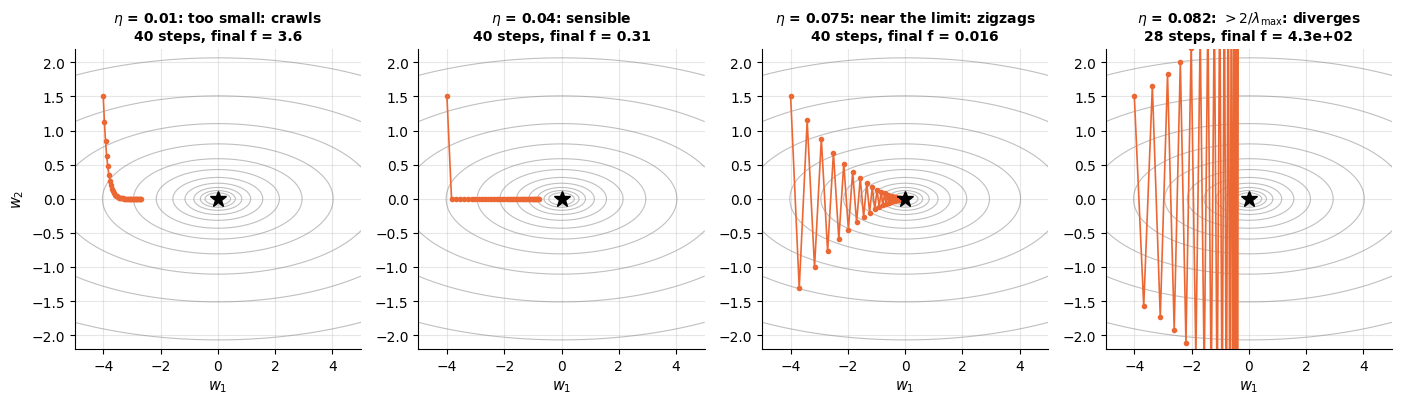

In [11]:
def gradient_descent(grad, w0, eta, n_steps):
    """Plain gradient descent; returns the trajectory as an array of shape (n_steps + 1, d).

    grad     function returning the gradient at a point
    w0       starting point (length d)
    eta      learning rate (step size)
    n_steps  number of updates w <- w - eta * grad(w); row 0 of the result is w0, row t the point after t steps
    """
    path = [np.asarray(w0, dtype=float)]
    for _ in range(n_steps):                               # _ : the loop counter itself is not needed
        path.append(path[-1] - eta * grad(path[-1]))       # path[-1] is the current (last) point
    return np.array(path)

A_bowl = np.diag([1.0, 25.0])             # eigenvalues 1 and 25: condition number 25
f_bowl = lambda w: 0.5 * w @ A_bowl @ w   # f(w) = 1/2 w^T A w
grad_bowl = lambda w: A_bowl @ w          # its gradient is A w
w_start = np.array([-4.0, 1.5])

g1, g2 = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-2.2, 2.2, 200))
F = 0.5 * (A_bowl[0, 0] * g1 ** 2 + A_bowl[1, 1] * g2 ** 2)   # f on the whole grid at once (A is diagonal)
etas = [(0.01, "too small: crawls"), (0.04, "sensible"), (0.075, "near the limit: zigzags"), (0.082, "$> 2/\\lambda_{\\max}$: diverges")]

fig, axes = plt.subplots(1, 4, figsize=(17, 3.9))
for ax, (eta, label) in zip(axes, etas):
    path = gradient_descent(grad_bowl, w_start, eta, n_steps=40)
    # np.all(..., axis=1) is True for the rows (points) whose coordinates are all inside (-6, 6)
    path = path[np.all(np.abs(path) < 6, axis=1)]            # drop the part of a diverging path that is far off screen
    # np.logspace(-1, 2, 12): 12 levels from 10^-1 to 10^2, evenly spaced on a log scale
    ax.contour(g1, g2, F, levels=np.logspace(-1, 2, 12), colors="gray", alpha=0.5, linewidths=0.8)
    ax.plot(path[:, 0], path[:, 1], marker="o", ms=3, lw=1.2, color=PALETTE[1])
    ax.plot(0, 0, marker="*", ms=12, color="black")          # the minimum
    ax.set_xlim(-5, 5)
    ax.set_ylim(-2.2, 2.2)
    # :.2g prints 2 significant digits, switching to scientific notation for very large or small values
    ax.set_title(f"$\\eta$ = {eta}: {label}\n{len(path) - 1} steps, final f = {f_bowl(path[-1]):.2g}", fontsize=10)
    ax.set_xlabel("$w_1$")
axes[0].set_ylabel("$w_2$")
plt.show()

Along $w_2$ (eigenvalue 25) the step is either tiny, well chosen, oscillating, or
explosive; along $w_1$ (eigenvalue 1) progress is slow in every panel because $\eta$ is
capped by the steep direction. Conditioning is the practical reason why **feature scaling**
matters for gradient-based models: features on different scales produce a loss surface
that is elongated along the small-scale feature, $\kappa$ becomes huge, and gradient
descent crawls. Compare the same optimiser on a well-conditioned and an ill-conditioned
bowl, each with its own near-optimal learning rate ($\eta^\star = 2/(\lambda_{\max} +
\lambda_{\min})$ balances the fastest and slowest directions):

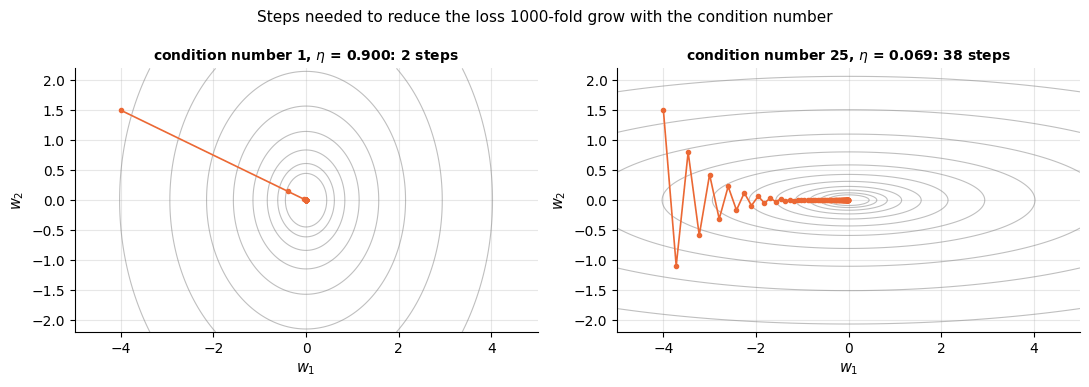

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
for ax, kappa in zip(axes, [1, 25]):
    A_k = np.diag([1.0, float(kappa)])                         # eigenvalues 1 and kappa
    eta = 0.9 * 2 / (kappa + 1)                                # 90% of the optimal step for this problem
    path = gradient_descent(lambda w: A_k @ w, w_start, eta, n_steps=80)
    losses = 0.5 * np.einsum("ti,ij,tj->t", path, A_k, path)   # the loss 1/2 w^T A w at every step t -> (81,)
    # argmax of a True/False array is the index of the first True: the first step whose loss is below
    # 1/1000 of the starting loss; if that never happens, report the full 80 steps
    n_needed = int(np.argmax(losses < 1e-3 * losses[0])) if np.any(losses < 1e-3 * losses[0]) else 80
    Fk = 0.5 * (g1 ** 2 + kappa * g2 ** 2)
    ax.contour(g1, g2, Fk, levels=np.logspace(-1, 2, 12), colors="gray", alpha=0.5, linewidths=0.8)
    ax.plot(path[:, 0], path[:, 1], marker="o", ms=3, lw=1.2, color=PALETTE[1])
    ax.set_xlim(-5, 5)
    ax.set_ylim(-2.2, 2.2)
    ax.set_title(f"condition number {kappa}, $\\eta$ = {eta:.3f}: {n_needed} steps", fontsize=10)
    ax.set_xlabel("$w_1$")
    ax.set_ylabel("$w_2$")
fig.suptitle("Steps needed to reduce the loss 1000-fold grow with the condition number", fontsize=11)
plt.tight_layout()
plt.show()

### 2.4 Non-convex functions: local minima and the role of initialisation

Real objectives — neural-network losses, $k$-means, matrix factorisation — are not bowls.
Himmelblau's function, $f(x, y) = (x^2 + y - 11)^2 + (x + y^2 - 7)^2$, is a standard test
case with four global minima (all with $f = 0$), a local maximum in the middle and saddle
points between the basins. Gradient descent from different starting points ends in
different minima: *which* solution you get depends on the initialisation. That is a fact
of life in deep learning (careful initialisation and momentum, which also helps with the zigzagging above, are the usual remedies).

gradient check: relative error 2.0e-11


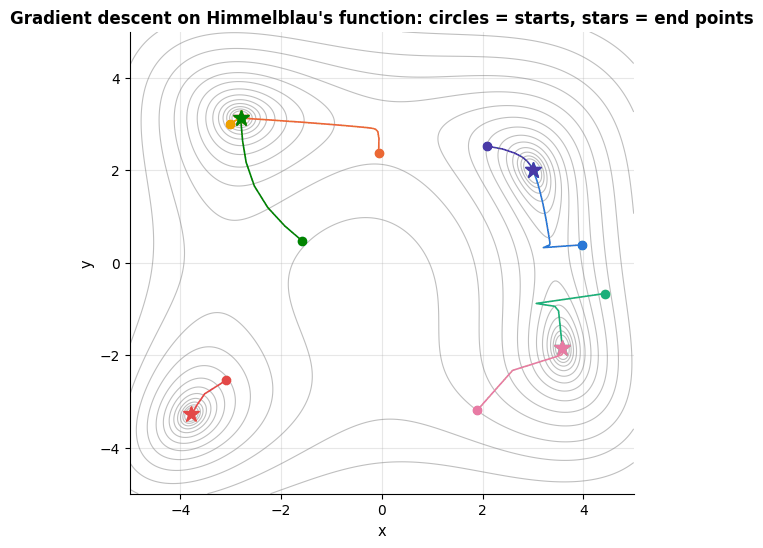

distinct minima reached: [(-3.78, -3.28), (-2.81, 3.13), (3.0, 2.0), (3.58, -1.85)]


In [13]:
def himmelblau(w):
    """Himmelblau's function f(x, y) = (x^2 + y - 11)^2 + (x + y^2 - 7)^2 at w = (x, y).

    x and y may also be whole grids of the same shape, which is how the contour plot below evaluates it.
    """
    x, y = w
    return (x ** 2 + y - 11) ** 2 + (x + y ** 2 - 7) ** 2

def grad_himmelblau(w):
    """Analytic gradient (df/dx, df/dy) of Himmelblau's function at w = (x, y), as a length-2 array."""
    x, y = w
    return np.array([4 * x * (x ** 2 + y - 11) + 2 * (x + y ** 2 - 7),
                     2 * (x ** 2 + y - 11) + 4 * y * (x + y ** 2 - 7)])

print(f"gradient check: relative error {relative_error(grad_himmelblau([1.0, 2.0]), numerical_gradient(himmelblau, [1.0, 2.0])):.1e}")

hx, hy = np.meshgrid(np.linspace(-5, 5, 300), np.linspace(-5, 5, 300))
H = himmelblau((hx, hy))                         # pass the two grids as one tuple -> f on the whole (300, 300) grid
starts = rng.uniform(-4.5, 4.5, size=(8, 2))     # 8 random starting points, uniform in the square [-4.5, 4.5)^2
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.contour(hx, hy, H, levels=np.logspace(0, 3, 15), colors="gray", alpha=0.5, linewidths=0.8)
found = []
for i, w0 in enumerate(starts):
    path = gradient_descent(grad_himmelblau, w0, eta=0.01, n_steps=300)
    ax.plot(path[:, 0], path[:, 1], lw=1.2, color=PALETTE[i % len(PALETTE)])   # % wraps the index around the palette
    ax.plot(*path[0], marker="o", color=PALETTE[i % len(PALETTE)])            # *path[0] unpacks the start into x, y
    ax.plot(*path[-1], marker="*", ms=12, color=PALETTE[i % len(PALETTE)])
    # the end point rounded to 2 decimals, as a tuple of plain floats so that set() below can remove duplicates
    found.append(tuple(float(v) for v in path[-1].round(2)))
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Gradient descent on Himmelblau's function: circles = starts, stars = end points")
plt.show()
print("distinct minima reached:", sorted(set(found)))

### 2.5 Convexity

A function is **convex** if the line segment between any two points on its graph lies
above the graph:

$$
f\big(\alpha\mathbf{x} + (1-\alpha)\mathbf{y}\big) \;\le\; \alpha f(\mathbf{x}) + (1-\alpha) f(\mathbf{y})
\qquad \text{for all } \mathbf{x}, \mathbf{y} \text{ and } \alpha \in [0, 1].
$$

For twice-differentiable functions this is equivalent to a PSD Hessian everywhere. Convex
functions have one property that makes them precious: **every local minimum is a global
minimum**, so gradient descent (with a small enough step) cannot get stuck, and a zero
gradient certifies optimality. Least squares, ridge, lasso, logistic regression and support
vector machines all have convex objectives (Boyd & Vandenberghe, 2004, is the reference);
$k$-means, matrix factorisation and neural networks do not — which is why for those we
worry about initialisation, restarts and the choice of optimiser.

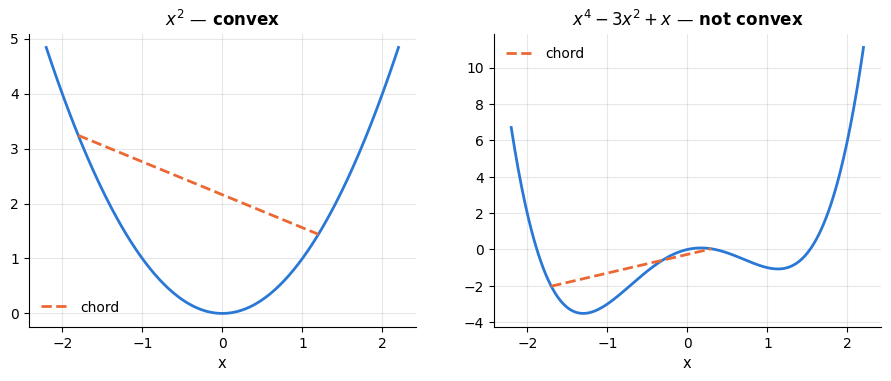

Himmelblau Hessian eigenvalues at the global minimum (3, 2) : [25.7 82.3]
Himmelblau Hessian eigenvalues at the local maximum         : [-45.6 -16.1]
Himmelblau Hessian eigenvalues at the saddle point          : [-14.1  97.5]


In [14]:
def numerical_hessian(grad, w, eps=1e-5):
    """Hessian by central differences of the (analytic) gradient.

    Column i is the change in the gradient when w_i moves by +-eps. Returns a (d, d) matrix,
    symmetrised by averaging with its transpose (round-off makes the raw estimate slightly asymmetric).
    """
    w = np.asarray(w, dtype=float)
    Hm = np.zeros((len(w), len(w)))
    for i in range(len(w)):
        step = np.zeros_like(w)
        step[i] = eps
        Hm[:, i] = (grad(w + step) - grad(w - step)) / (2 * eps)
    return (Hm + Hm.T) / 2

xs = np.linspace(-2.2, 2.2, 300)
convex, nonconvex = xs ** 2, xs ** 4 - 3 * xs ** 2 + xs
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
# zip walks through four lists in step: panel, function values, title, and the two x positions (a, b) of the chord
for ax, fvals, name, (a, b) in zip(axes, [convex, nonconvex], ["$x^2$ — convex", "$x^4 - 3x^2 + x$ — not convex"], [(-1.8, 1.2), (-1.7, 0.3)]):
    ax.plot(xs, fvals, lw=2)
    fa, fb = np.interp([a, b], xs, fvals)     # np.interp: read the function values at a and b off the sampled curve
    ax.plot([a, b], [fa, fb], color=PALETTE[1], lw=2, ls="--", label="chord")
    ax.set_title(name)
    ax.set_xlabel("x")
    ax.legend()
plt.show()

# three stationary points of Himmelblau's function (the last two given to 3 decimals)
for name, point in [("global minimum (3, 2)", [3.0, 2.0]), ("local maximum", [-0.271, -0.923]), ("saddle point", [3.385, 0.074])]:
    eig = np.linalg.eigvalsh(numerical_hessian(grad_himmelblau, point))
    print(f"Himmelblau Hessian eigenvalues at the {name:22s}: {eig.round(1)}")

The chord of the non-convex function dips *below* the graph, and the Hessian eigenvalues at
Himmelblau's stationary points tell the three stories: both positive at a minimum, both
negative at the maximum, one of each at the saddle.

## 3. Probability

### 3.1 Random variables, expectation and variance

A **random variable** $X$ is a quantity whose value is determined by chance — the outcome
of a die, the number of support tickets a customer files, the noise in a measurement. Its
**distribution** assigns probabilities to values: a probability mass function $p(x) =
P(X = x)$ for discrete variables, a density $p(x)$ (with $P(a \le X \le b) = \int_a^b p(x)\,dx$)
for continuous ones. Two numbers summarise a distribution:

$$
\mathbb{E}[X] = \sum_x x\,p(x) \ \text{ or } \int x\,p(x)\,dx, \qquad
\operatorname{Var}[X] = \mathbb{E}\big[(X - \mathbb{E}[X])^2\big] = \mathbb{E}[X^2] - \mathbb{E}[X]^2 .
$$

Expectation is *linear* — $\mathbb{E}[aX + bY] = a\mathbb{E}[X] + b\mathbb{E}[Y]$ always,
whether or not $X$ and $Y$ are related — while variance scales quadratically,
$\operatorname{Var}[aX] = a^2\operatorname{Var}[X]$, and adds only for *independent*
variables: $\operatorname{Var}[X + Y] = \operatorname{Var}[X] + \operatorname{Var}[Y]$ if
$X \perp Y$. The standard deviation $\sqrt{\operatorname{Var}[X]}$ is in the units of $X$.
In practice we estimate both from a sample by the sample mean and sample variance, and the
estimates get better with more data — that is the law of large numbers (section 3.5).

In [15]:
faces = np.arange(1, 7)                   # the outcomes 1..6
p_faces = np.full(6, 1 / 6)               # np.full(shape, value): six entries, each 1/6
mean_exact = faces @ p_faces              # E[X] = sum of x p(x), written as a dot product
var_exact = (faces ** 2) @ p_faces - mean_exact ** 2     # Var[X] = E[X^2] - E[X]^2
print(f"fair die: E[X] = {mean_exact:.4f}, Var[X] = {var_exact:.4f} (= 35/12)")
for n in [10, 1_000, 100_000]:
    rolls = rng.integers(1, 7, size=n)    # random integers from 1 up to 6 (the upper bound 7 is excluded)
    # {n:>7d}: an integer right-aligned in 7 characters; ddof=1 gives the sample variance (divide by n - 1)
    print(f"  n = {n:>7d} rolls: sample mean {rolls.mean():.4f}, sample variance {rolls.var(ddof=1):.4f}")

fair die: E[X] = 3.5000, Var[X] = 2.9167 (= 35/12)
  n =      10 rolls: sample mean 3.9000, sample variance 2.1000
  n =    1000 rolls: sample mean 3.4170, sample variance 3.0862
  n =  100000 rolls: sample mean 3.5052, sample variance 2.9090


### 3.2 Common distributions

| Distribution | Values | Parameters | $p(x)$ | Mean | Variance | Typical use |
|---|---|---|---|---|---|---|
| Bernoulli | $\{0, 1\}$ | $p$ | $p^x(1-p)^{1-x}$ | $p$ | $p(1-p)$ | a binary label, one coin flip |
| Binomial | $\{0, \dots, n\}$ | $n, p$ | $\binom{n}{x}p^x(1-p)^{n-x}$ | $np$ | $np(1-p)$ | number of successes in $n$ flips |
| Poisson | $\{0, 1, 2, \dots\}$ | $\lambda$ | $e^{-\lambda}\lambda^x / x!$ | $\lambda$ | $\lambda$ | counts of rare events (tickets, clicks) |
| Gaussian (normal) | $\mathbb{R}$ | $\mu, \sigma^2$ | $\frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\big(-\frac{(x-\mu)^2}{2\sigma^2}\big)$ | $\mu$ | $\sigma^2$ | measurement noise, sums of many effects |
| Uniform | $[a, b]$ | $a, b$ | $1/(b-a)$ | $(a+b)/2$ | $(b-a)^2/12$ | "no idea", random initialisation |
| Exponential | $[0, \infty)$ | $\lambda$ | $\lambda e^{-\lambda x}$ | $1/\lambda$ | $1/\lambda^2$ | waiting times; a skewed example |

The Bernoulli distribution is the model behind every binary classifier (notebook 7: the
classifier outputs $p$); the Gaussian is the model behind least squares (section 4.3); the
Poisson appears in count regression (notebook 6, §9). `scipy.stats` implements all of them
with the same interface (`pmf`/`pdf`, `cdf`, `mean`, `var`, `rvs`).

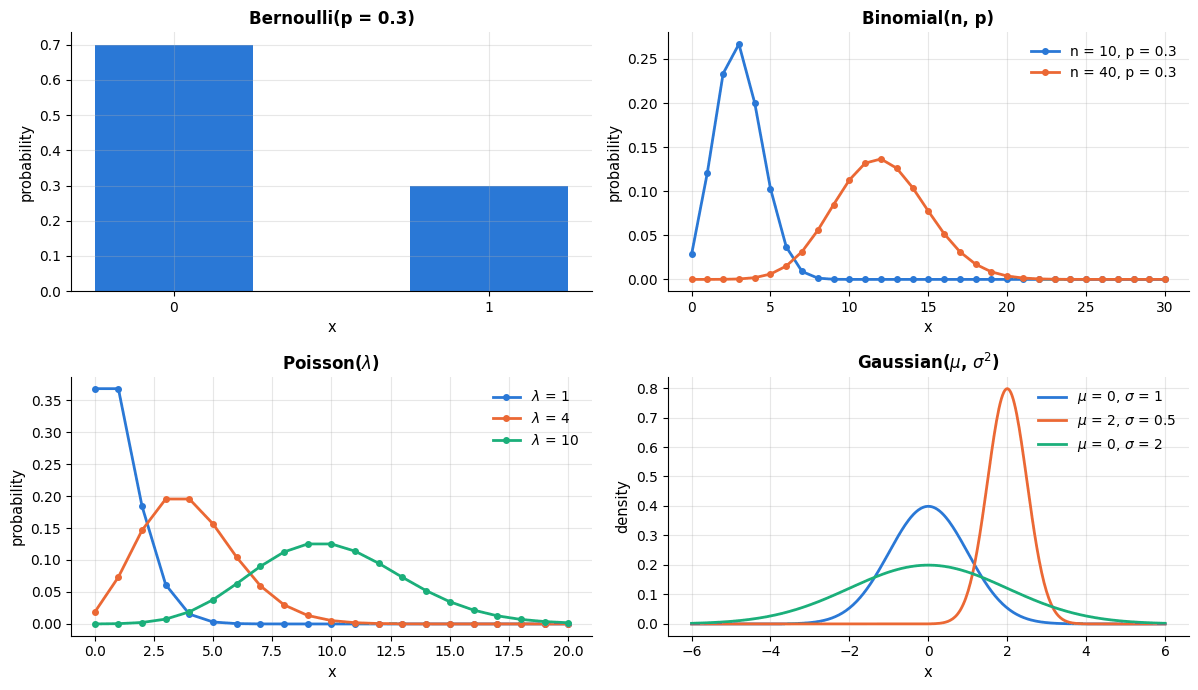

Poisson(4): theoretical mean 4.00 / var 4.00; from 100 000 samples: mean 3.995 / var 3.974


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))   # a 2 x 2 grid of panels; axes[row, col] picks one
ks = np.arange(0, 21)
# stats.bernoulli(0.3) is a scipy "frozen" distribution with p = 0.3; .pmf(k) gives P(X = k) for each k
axes[0, 0].bar([0, 1], stats.bernoulli(0.3).pmf([0, 1]), width=0.5, color=PALETTE[0])
axes[0, 0].set_title("Bernoulli(p = 0.3)")
axes[0, 0].set_xticks([0, 1])
ks_binom = np.arange(0, 31)
for n_trials, color in [(10, PALETTE[0]), (40, PALETTE[1])]:
    axes[0, 1].plot(ks_binom, stats.binom(n_trials, 0.3).pmf(ks_binom), marker="o", ms=4, color=color, label=f"n = {n_trials}, p = 0.3")
axes[0, 1].set_title("Binomial(n, p)")
axes[0, 1].legend()
for lam_, color in [(1, PALETTE[0]), (4, PALETTE[1]), (10, PALETTE[2])]:     # lam_ is the Poisson rate lambda
    axes[1, 0].plot(ks, stats.poisson(lam_).pmf(ks), marker="o", ms=4, color=color, label=f"$\\lambda$ = {lam_}")
axes[1, 0].set_title("Poisson($\\lambda$)")
axes[1, 0].legend()
xs = np.linspace(-6, 6, 400)
for mu, sd, color in [(0, 1, PALETTE[0]), (2, 0.5, PALETTE[1]), (0, 2, PALETTE[2])]:
    # stats.norm(mean, standard deviation) — note: the standard deviation, not the variance; .pdf gives the density
    axes[1, 1].plot(xs, stats.norm(mu, sd).pdf(xs), color=color, label=f"$\\mu$ = {mu}, $\\sigma$ = {sd}")
axes[1, 1].set_title("Gaussian($\\mu$, $\\sigma^2$)")
axes[1, 1].legend()
for ax in axes[0]:                        # axes[0] is the top row of panels
    ax.set_ylabel("probability")
axes[1, 0].set_ylabel("probability")
axes[1, 1].set_ylabel("density")
for ax in axes.ravel():                   # .ravel() flattens the 2 x 2 grid into a sequence of 4 panels
    ax.set_xlabel("x")
plt.tight_layout()
plt.show()

samples = rng.poisson(4, size=100_000)    # 100 000 random draws from Poisson(4)
# .mean() / .var() of a frozen distribution are the exact theoretical values
print(f"Poisson(4): theoretical mean {stats.poisson(4).mean():.2f} / var {stats.poisson(4).var():.2f}; "
      f"from 100 000 samples: mean {samples.mean():.3f} / var {samples.var():.3f}")

### 3.3 Joint, marginal and conditional probabilities; independence

For two random variables the **joint** distribution $P(X = x, Y = y)$ says how often each
combination occurs. Summing over one variable gives the **marginal** of the other,
$P(X = x) = \sum_y P(X = x, Y = y)$, and dividing gives the **conditional**,

$$
P(Y = y \mid X = x) = \frac{P(X = x, Y = y)}{P(X = x)} \qquad \text{(the product rule: } P(x, y) = P(y \mid x)\,P(x)\text{)}.
$$

$X$ and $Y$ are **independent** if $P(x, y) = P(x)P(y)$ for all $x, y$ — equivalently,
knowing $X$ does not change the distribution of $Y$. Classification is the business of
estimating $P(y \mid \mathbf{x})$; naive Bayes (notebook 8) assumes the features are
independent given the class; decision trees (notebook 9) look for the feature whose
conditional distributions differ most. We can compute all of this from a table. Here
$X$ = contract type and $Y$ = churned, from the (cleaned) churn data:

In [17]:
churn = load_churn()                      # the cleaned customer-churn table (one row per customer)
# pd.crosstab counts every (contract, churned) combination; normalize=True divides the counts by the total
joint = pd.crosstab(churn["contract"], churn["churned"], normalize=True)   # P(contract, churned)
marg_contract = joint.sum(axis=1)                                            # P(contract)
marg_churn = joint.sum(axis=0)                                               # P(churned)
# .div(series, axis=0) divides each row by the matching entry of the series (matched by row label)
conditional = joint.div(marg_contract, axis=0)                               # P(churned | contract)
# np.outer(a, b) is the table a[i] * b[j], here (3 contracts) x (2 churn values)
independent = np.outer(marg_contract, marg_churn)                            # what the joint would be under independence

print("joint P(contract, churned):")
display(joint.round(3))                   # display() renders the table nicely even in the middle of a cell
print("marginal P(churned = 1):", marg_churn[1].round(3))      # [1] selects the entry with label 1, not position 1
# conditional[1] is the column churned = 1; .to_dict() turns it into {contract: probability}
print("conditional P(churned = 1 | contract):", conditional[1].round(3).to_dict())
print("\nlargest |joint - P(contract) P(churned)|:", np.abs(joint.to_numpy() - independent).max().round(3),
      "-> far from independent; contract type carries information about churn")

joint P(contract, churned):


churned,0,1
contract,,
Month-to-month,0.294,0.265
One year,0.197,0.047
Two year,0.183,0.014


marginal P(churned = 1): 0.326
conditional P(churned = 1 | contract): {'Month-to-month': 0.474, 'One year': 0.193, 'Two year': 0.072}

largest |joint - P(contract) P(churned)|: 0.083 -> far from independent; contract type carries information about churn


### 3.4 Bayes' theorem

Applying the product rule in both orders, $P(x, y) = P(y \mid x)P(x) = P(x \mid y)P(y)$,
and dividing:

$$
P(y \mid x) \;=\; \frac{P(x \mid y)\,P(y)}{P(x)}, \qquad P(x) = \sum_{y'} P(x \mid y')\,P(y') .
$$

In the language of inference: the **posterior** probability of a hypothesis $y$ given
evidence $x$ equals the **likelihood** of the evidence under the hypothesis, times the
**prior** probability of the hypothesis, normalised by the total probability of the
evidence. The classic worked example shows why intuition fails here. A test for a disease
with **prevalence** 1 % has **sensitivity** $P(+ \mid D) = 0.99$ and **specificity**
$P(- \mid \neg D) = 0.95$. You test positive. How likely are you to have the disease?

$$
P(D \mid +) = \frac{0.99 \times 0.01}{0.99 \times 0.01 + 0.05 \times 0.99} = \frac{0.0099}{0.0099 + 0.0495} \approx 0.167 .
$$

Only one in six positives is a true positive: because the disease is rare, the 5 % of
healthy people who test positive outnumber the sick ones. *Natural frequencies* make this
transparent — of 10 000 people, 99 of the 100 sick ones and 495 of the 9 900 healthy ones
test positive. The same mechanism governs every classifier on an imbalanced problem:
precision depends on the base rate, not only on the model (notebook 7).

P(disease | positive test) = 0.167
natural frequencies out of 10000: 99 true positives vs 495 false positives


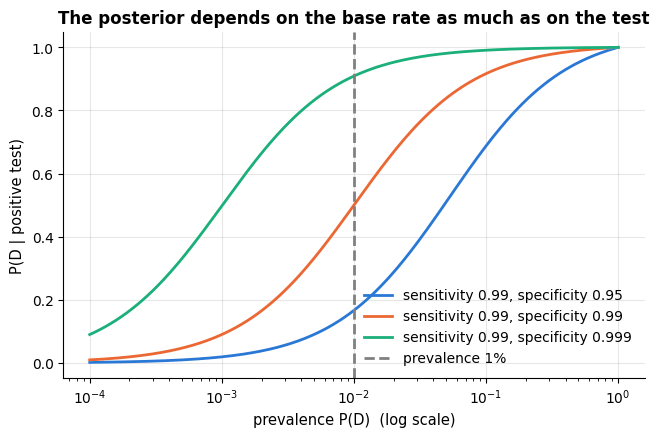

In [18]:
def posterior_positive(prevalence, sensitivity, specificity):
    """P(disease | positive test) by Bayes' theorem.

    prevalence is P(D), sensitivity P(+ | D), specificity P(- | healthy). Works element by element
    when prevalence is an array, which the plot below uses.
    """
    p_pos_given_d = sensitivity
    p_pos_given_healthy = 1 - specificity              # false-positive rate
    evidence = p_pos_given_d * prevalence + p_pos_given_healthy * (1 - prevalence)   # P(+), by total probability
    return p_pos_given_d * prevalence / evidence

print(f"P(disease | positive test) = {posterior_positive(0.01, 0.99, 0.95):.3f}")
N = 10_000
sick = N * 0.01
print(f"natural frequencies out of {N}: {sick * 0.99:.0f} true positives vs {(N - sick) * 0.05:.0f} false positives")

prev = np.logspace(-4, 0, 300)            # 300 prevalences from 10^-4 to 1, evenly spaced on a log scale
fig, ax = plt.subplots()
for sens, spec in [(0.99, 0.95), (0.99, 0.99), (0.99, 0.999)]:
    ax.plot(prev, posterior_positive(prev, sens, spec), lw=2, label=f"sensitivity {sens}, specificity {spec}")
ax.axvline(0.01, color="gray", ls="--", label="prevalence 1%")
ax.set_xscale("log")
ax.set_xlabel("prevalence P(D)  (log scale)")
ax.set_ylabel("P(D | positive test)")
ax.set_title("The posterior depends on the base rate as much as on the test")
ax.legend()
plt.show()

Bayes' theorem is also a *learning rule*: with $y$ = model parameters and $x$ = data, the
posterior over parameters is proportional to likelihood × prior, which is the idea behind
maximum a posteriori estimation and regularisation in section 4.4 and behind Bayesian
methods generally (Murphy, 2022; Bishop, 2006).

### 3.5 The law of large numbers and the central limit theorem, by simulation

Two theorems justify most of statistics and, with it, most of machine learning. Let
$X_1, \dots, X_n$ be i.i.d. with mean $\mu$ and variance $\sigma^2$, and let
$\bar{X}_n = \frac{1}{n}\sum_i X_i$ be the sample mean.

- **Law of large numbers (LLN):** $\bar{X}_n \to \mu$ as $n \to \infty$. Averages settle
  down. This is why the empirical risk (average loss on a sample, notebook 5) is a sensible
  proxy for the true risk (expected loss), and why test-set accuracy estimates generalisation.
- **Central limit theorem (CLT):** whatever the shape of the distribution of the $X_i$,
  $\sqrt{n}(\bar{X}_n - \mu)/\sigma \to \mathcal{N}(0, 1)$ in distribution; for finite $n$,
  $\bar{X}_n \approx \mathcal{N}(\mu, \sigma^2/n)$. Averages are approximately Gaussian with
  a standard deviation — the **standard error** — that shrinks like $1/\sqrt{n}$. This is why
  confidence intervals look like $\bar{x} \pm 1.96\, s/\sqrt{n}$ (section 4.5), why Gaussian
  noise is the default assumption (noise is often a sum of many small effects), and why
  halving the standard error of an estimate costs four times the data.

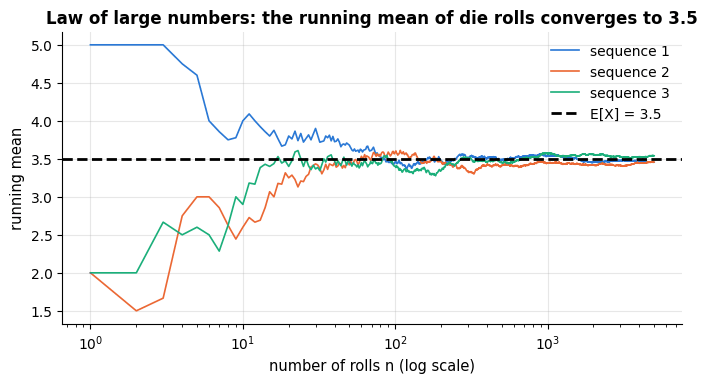

In [19]:
n_max = 5_000
fig, ax = plt.subplots(figsize=(8, 3.8))
for i in range(3):                        # three independent sequences of die rolls
    rolls = rng.integers(1, 7, size=n_max)
    # cumulative sums divided by 1, 2, ..., n_max: the mean of the first n rolls, for every n
    running_mean = np.cumsum(rolls) / np.arange(1, n_max + 1)
    ax.plot(np.arange(1, n_max + 1), running_mean, lw=1.2, color=PALETTE[i], label=f"sequence {i + 1}")
ax.axhline(3.5, color="black", ls="--", label="E[X] = 3.5")
ax.set_xscale("log")
ax.set_xlabel("number of rolls n (log scale)")
ax.set_ylabel("running mean")
ax.set_title("Law of large numbers: the running mean of die rolls converges to 3.5")
ax.legend()
plt.show()

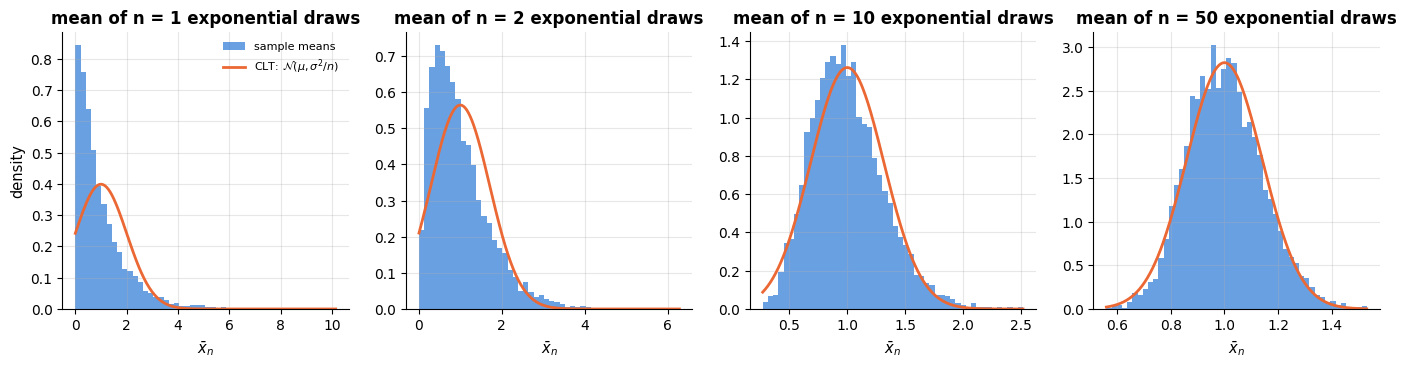

In [20]:
n_reps = 5_000
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, n in zip(axes, [1, 2, 10, 50]):
    # a (5000, n) array of draws; .mean(axis=1) averages each row -> 5000 sample means of size n
    means = rng.exponential(scale=1.0, size=(n_reps, n)).mean(axis=1)     # exponential(1): mean 1, variance 1, very skewed
    # density=True scales the bars so their total area is 1, comparable with the density curve
    ax.hist(means, bins=50, density=True, color=PALETTE[0], alpha=0.7, label="sample means")
    xs = np.linspace(means.min(), means.max(), 300)
    # the CLT prediction: a normal density with mean 1 and standard deviation 1 / sqrt(n)
    ax.plot(xs, stats.norm(1.0, 1.0 / np.sqrt(n)).pdf(xs), color=PALETTE[1], lw=2, label="CLT: $\\mathcal{N}(\\mu, \\sigma^2/n)$")
    ax.set_title(f"mean of n = {n} exponential draws")
    ax.set_xlabel("$\\bar{x}_n$")
axes[0].set_ylabel("density")
axes[0].legend(fontsize=8)
plt.show()

With $n = 1$ the histogram is the skewed exponential density itself; by $n = 50$ it is
indistinguishable from the Gaussian predicted by the CLT, and its width has shrunk by
$\sqrt{50} \approx 7$.

## 4. Statistics: estimators, likelihood, uncertainty

### 4.1 Estimators, bias and variance

An **estimator** is a rule that turns a sample into a guess for an unknown quantity: the
sample mean estimates $\mu$, the sample variance estimates $\sigma^2$, a fitted model
estimates the true regression function. Because the sample is random, so is the estimate,
and we judge an estimator $\hat\theta$ of $\theta$ by the distribution of its errors:

$$
\operatorname{bias}(\hat\theta) = \mathbb{E}[\hat\theta] - \theta, \qquad
\operatorname{Var}[\hat\theta] = \mathbb{E}\big[(\hat\theta - \mathbb{E}[\hat\theta])^2\big], \qquad
\operatorname{MSE}(\hat\theta) = \mathbb{E}\big[(\hat\theta - \theta)^2\big] = \operatorname{bias}^2 + \operatorname{Var}.
$$

The last identity is the bias–variance decomposition, which notebook 5 applies to
predictions of a model rather than to a single parameter. A classic surprise: the "natural"
variance estimator $\frac{1}{n}\sum(x_i - \bar{x})^2$ is biased — its expectation is
$\frac{n-1}{n}\sigma^2$, because $\bar{x}$ is closer to the data than $\mu$ is — which is
why `np.var(x, ddof=1)` divides by $n - 1$. Yet the biased version has the *smaller* mean
squared error: unbiasedness is not the same as accuracy.

In [21]:
n, n_reps, sigma2 = 5, 20_000, 1.0
samples = rng.normal(0, np.sqrt(sigma2), size=(n_reps, n))   # 20 000 samples (rows) of size 5 from N(0, 1)
var_biased = samples.var(axis=1, ddof=0)            # divide by n
var_unbiased = samples.var(axis=1, ddof=1)          # divide by n - 1
for name, est in [("1/n", var_biased), ("1/(n-1)", var_unbiased)]:
    bias = est.mean() - sigma2                      # average estimate minus the true value
    # est.var() is the variance of the estimator across the 20 000 repetitions; MSE = mean squared error
    print(f"{name:8s} estimator of the variance (n = {n}): mean {est.mean():.3f}  bias {bias:+.3f}  "
          f"variance {est.var():.3f}  MSE {((est - sigma2) ** 2).mean():.3f}")
print(f"theory: E[1/n estimator] = (n-1)/n sigma^2 = {(n - 1) / n:.3f}")

1/n      estimator of the variance (n = 5): mean 0.798  bias -0.202  variance 0.318  MSE 0.359
1/(n-1)  estimator of the variance (n = 5): mean 0.997  bias -0.003  variance 0.496  MSE 0.496
theory: E[1/n estimator] = (n-1)/n sigma^2 = 0.800


### 4.2 Maximum likelihood

The most important estimation principle in this course (Fisher, 1922): choose the
parameters under which the observed data are most probable. For i.i.d. data
$x_1, \dots, x_n$ with a model $p(x \mid \theta)$, the **likelihood** is
$L(\theta) = \prod_i p(x_i \mid \theta)$, and because products of small numbers are
numerically hopeless and sums are easier to differentiate, we maximise the
**log-likelihood** $\ell(\theta) = \sum_i \log p(x_i \mid \theta)$:

$$
\hat\theta_{\text{MLE}} = \arg\max_\theta\, \ell(\theta) .
$$

**Bernoulli.** Observing $k$ ones among $n$ flips, $\ell(p) = k\log p + (n-k)\log(1-p)$.
Setting $\ell'(p) = k/p - (n-k)/(1-p) = 0$ gives $\hat p = k/n$: the observed frequency.

**Gaussian.** With $\ell(\mu, \sigma^2) = -\frac{n}{2}\log(2\pi\sigma^2) -
\frac{1}{2\sigma^2}\sum_i (x_i - \mu)^2$, the derivative in $\mu$ vanishes at
$\hat\mu = \bar{x}$, and the derivative in $\sigma^2$, $-\frac{n}{2\sigma^2} +
\frac{1}{2\sigma^4}\sum_i(x_i - \hat\mu)^2 = 0$, gives $\hat\sigma^2 = \frac{1}{n}\sum_i
(x_i - \bar{x})^2$ — the *biased* variance estimator of section 4.1. MLE is not
automatically unbiased; it is, under mild conditions, *consistent* (converges to the truth)
and *asymptotically efficient* (no consistent estimator has lower variance for large $n$),
which is why it is the default.

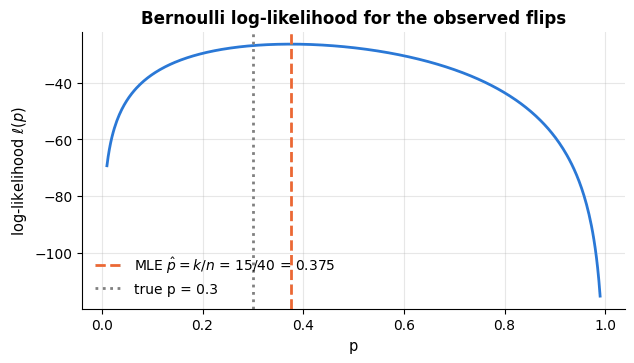

Gaussian MLE by numerical optimisation: mu = 2.0665, sigma^2 = 2.1908
closed form                           : mu = 2.0665, sigma^2 = 2.1908 (1/n, not 1/(n-1))


In [22]:
flips = rng.random(40) < 0.3                       # 40 Bernoulli(0.3) draws
k, n = flips.sum(), len(flips)                     # number of ones (True counts as 1) and number of flips
p_grid = np.linspace(0.01, 0.99, 400)             # candidate values of p (0 and 1 excluded: log(0) is -inf)
loglik = k * np.log(p_grid) + (n - k) * np.log(1 - p_grid)    # l(p) for every candidate at once

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(p_grid, loglik, lw=2)
ax.axvline(k / n, color=PALETTE[1], ls="--", label=f"MLE $\\hat p = k/n$ = {k}/{n} = {k / n:.3f}")
ax.axvline(0.3, color="gray", ls=":", label="true p = 0.3")
ax.set_xlabel("p")
ax.set_ylabel("log-likelihood $\\ell(p)$")
ax.set_title("Bernoulli log-likelihood for the observed flips")
ax.legend()
plt.show()

x_obs = rng.normal(loc=2.0, scale=1.5, size=200)
# .logpdf(x) is the log-density of each observation; optimising log(sigma) keeps sigma = exp(.) positive
neg_loglik = lambda theta: -np.sum(stats.norm(theta[0], np.exp(theta[1])).logpdf(x_obs))   # theta = (mu, log sigma)
# optimize.minimize(f, x0) searches numerically for the minimum of f starting from x0 (here with BFGS, the default
# for problems without bounds or constraints); it returns a result object whose .x is the minimiser
res = optimize.minimize(neg_loglik, x0=[0.0, 0.0])
mu_hat, sigma_hat = res.x[0], np.exp(res.x[1])
print(f"Gaussian MLE by numerical optimisation: mu = {mu_hat:.4f}, sigma^2 = {sigma_hat ** 2:.4f}")
print(f"closed form                           : mu = {x_obs.mean():.4f}, sigma^2 = {x_obs.var(ddof=0):.4f} (1/n, not 1/(n-1))")

### 4.3 Least squares is maximum likelihood; cross-entropy is negative log-likelihood

Two of the most important connections in machine learning follow from the previous
section in a few lines.

**Regression.** Assume $y_i = \mathbf{w}^\top\mathbf{x}_i + \varepsilon_i$ with Gaussian
noise $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$. Then $y_i \mid \mathbf{x}_i \sim
\mathcal{N}(\mathbf{w}^\top\mathbf{x}_i, \sigma^2)$ and

$$
\ell(\mathbf{w}) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n\big(y_i - \mathbf{w}^\top\mathbf{x}_i\big)^2 .
$$

The first term does not involve $\mathbf{w}$; maximising $\ell$ therefore means minimising
$\sum_i (y_i - \mathbf{w}^\top\mathbf{x}_i)^2 = \|\mathbf{X}\mathbf{w} - \mathbf{y}\|^2$.
**Least squares is the MLE under Gaussian noise.** (Laplacian noise would give least
absolute deviations; heavy-tailed noise motivates robust losses — notebook 6.)

**Classification.** Assume $y_i \in \{0, 1\}$ with $P(y_i = 1 \mid \mathbf{x}_i) = p_i =
\sigma(\mathbf{w}^\top\mathbf{x}_i)$, the logistic model. The Bernoulli log-likelihood is

$$
\ell(\mathbf{w}) = \sum_{i=1}^n \big[y_i\log p_i + (1 - y_i)\log(1 - p_i)\big],
\qquad
-\frac{1}{n}\ell(\mathbf{w}) = \text{the binary cross-entropy (log loss).}
$$

**Minimising cross-entropy is maximising the Bernoulli likelihood.** Its gradient is
$\nabla_\mathbf{w}(-\ell) = \mathbf{X}^\top(\mathbf{p} - \mathbf{y})$ — derived in notebook
7 — and its Hessian is PSD, so logistic regression is a convex problem. Both facts are
easy to verify numerically: minimise the negative log-likelihoods with a generic optimiser
and compare with the specialised solvers.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss      # the average binary cross-entropy of predicted probabilities

# --- regression: minimising the Gaussian negative log-likelihood == least squares ---
sigma_noise = 1.0
# the first term does not depend on w, so it does not move the minimum
gauss_nll = lambda w: 0.5 * n * np.log(2 * np.pi * sigma_noise ** 2) + np.sum((y_ls - X_ls @ w) ** 2) / (2 * sigma_noise ** 2)
w_mle = optimize.minimize(gauss_nll, x0=np.zeros(d)).x
w_lstsq = np.linalg.lstsq(X_ls, y_ls, rcond=None)[0]
print("Gaussian MLE :", w_mle.round(4))
print("least squares:", w_lstsq.round(4))

# --- classification: minimising the Bernoulli negative log-likelihood == logistic regression ---
sigmoid = lambda z: 1 / (1 + np.exp(-z))   # squashes any number into (0, 1)
n_c = 400
X_c = np.column_stack([np.ones(n_c), rng.normal(size=(n_c, 2))])          # intercept column + 2 features
w_true = np.array([-0.5, 2.0, -1.0])
# each label is 1 with probability sigmoid(w_true . x) (a Bernoulli draw); .astype(float) turns True/False into 1.0/0.0
y_c = (rng.random(n_c) < sigmoid(X_c @ w_true)).astype(float)

def bernoulli_nll(w):
    """Negative Bernoulli log-likelihood (the summed cross-entropy) of the weights w on the data (X_c, y_c)."""
    p = np.clip(sigmoid(X_c @ w), 1e-12, 1 - 1e-12)     # np.clip keeps p away from 0 and 1, so log() stays finite
    return -np.sum(y_c * np.log(p) + (1 - y_c) * np.log(1 - p))

grad_nll = lambda w: X_c.T @ (sigmoid(X_c @ w) - y_c)    # gradient X^T (p - y)
print(f"\ngradient check for the cross-entropy gradient: relative error {relative_error(grad_nll(w_true), numerical_gradient(bernoulli_nll, w_true)):.1e}")
# jac= passes the analytic gradient to the optimiser; method="BFGS" is a quasi-Newton method
w_ce = optimize.minimize(bernoulli_nll, x0=np.zeros(3), jac=grad_nll, method="BFGS").x
logreg = LogisticRegression(C=1e12, fit_intercept=False).fit(X_c, y_c)   # huge C = (effectively) no regularisation; intercept is a column of X_c
print("minimised cross-entropy :", w_ce.round(4))
print("LogisticRegression      :", logreg.coef_[0].round(4))     # coef_ has shape (1, 3); [0] takes the row
# predict_proba returns an (n, 2) array [P(y = 0), P(y = 1)] per row; [:, 1] keeps P(y = 1)
print(f"cross-entropy per sample: by hand {bernoulli_nll(w_ce) / n_c:.5f}, sklearn log_loss {log_loss(y_c, logreg.predict_proba(X_c)[:, 1]):.5f}")

Gaussian MLE : [ 1.0794 -2.0757  0.4947  3.0463]
least squares: [ 1.0794 -2.0757  0.4947  3.0463]

gradient check for the cross-entropy gradient: relative error 7.5e-11
minimised cross-entropy : [-0.4143  2.3131 -1.2272]
LogisticRegression      : [-0.4142  2.3128 -1.2269]
cross-entropy per sample: by hand 0.39780, sklearn log_loss 0.39780


### 4.4 Maximum a posteriori estimation: regularisation as a prior

Bayes' theorem applied to parameters says $p(\mathbf{w} \mid \mathcal{D}) \propto
p(\mathcal{D} \mid \mathbf{w})\,p(\mathbf{w})$. The **maximum a posteriori** (MAP) estimate
maximises the posterior, i.e. $\log p(\mathcal{D} \mid \mathbf{w}) + \log p(\mathbf{w})$.
With the Gaussian regression likelihood of section 4.3 and a Gaussian prior
$\mathbf{w} \sim \mathcal{N}(\mathbf{0}, \tau^2\mathbf{I})$, whose log-density is
$-\|\mathbf{w}\|_2^2 / (2\tau^2)$ plus a constant, the MAP objective is

$$
\min_\mathbf{w}\ \frac{1}{2\sigma^2}\|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 + \frac{1}{2\tau^2}\|\mathbf{w}\|_2^2
\;\;\Longleftrightarrow\;\;
\min_\mathbf{w}\ \|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 + \lambda\|\mathbf{w}\|_2^2, \quad \lambda = \sigma^2/\tau^2 .
$$

This is **ridge regression** (notebook 6). A Laplace prior $p(w_j) \propto e^{-|w_j|/b}$
gives the $\ell_1$ penalty of the **lasso** instead. Regularisation, then, is a statement of
prior belief that the weights are small — and the strength $\lambda$ trades the prior
against the data, which is why it must shrink (relatively) as $n$ grows.

In [24]:
from sklearn.linear_model import Ridge   # least squares plus the penalty alpha * ||w||^2

lam = 5.0
map_objective = lambda w: np.sum((y_ls - X_ls @ w) ** 2) + lam * np.sum(w ** 2)   # ||X w - y||^2 + lambda ||w||^2
w_map = optimize.minimize(map_objective, x0=np.zeros(d)).x
w_ridge = Ridge(alpha=lam, fit_intercept=False).fit(X_ls, y_ls).coef_   # alpha is scikit-learn's name for lambda
print("MAP with a Gaussian prior:", w_map.round(4))
print("Ridge(alpha = 5)         :", w_ridge.round(4))
print("unregularised MLE        :", w_lstsq.round(4), "<- the prior pulls every weight towards 0")

MAP with a Gaussian prior: [ 0.96   -1.9524  0.4434  2.752 ]
Ridge(alpha = 5)         : [ 0.96   -1.9524  0.4434  2.752 ]
unregularised MLE        : [ 1.0794 -2.0757  0.4947  3.0463] <- the prior pulls every weight towards 0


### 4.5 Confidence intervals and the bootstrap

A point estimate without a measure of uncertainty is a guess. A **95 % confidence
interval** for a parameter is an interval computed from the data by a procedure that, over
repeated samples, contains the true value 95 % of the time. (It is a statement about the
*procedure*; any particular interval either contains the truth or does not.) For the mean,
the CLT gives the standard error $s/\sqrt{n}$ and the interval

$$
\bar{x} \;\pm\; 1.96\,\frac{s}{\sqrt{n}} .
$$

This formula needs $n$ large enough for the CLT to have kicked in, and there is no such
formula for most other statistics — a median, a correlation, the test accuracy of a
model. The **bootstrap** (Efron, 1979) replaces the theory with computation: since we
cannot draw new samples from the population, we treat the sample as the population and
draw new samples *from it*, with replacement.

1. For $b = 1, \dots, B$: draw $n$ observations with replacement from the data and compute
   the statistic $\hat\theta^{*}_b$ on the resample.
2. The spread of $\{\hat\theta^{*}_b\}$ estimates the sampling distribution of $\hat\theta$;
   the 2.5 % and 97.5 % quantiles give a **percentile interval**.

It works for any statistic, and it is how later notebooks put error bars on model scores.
Let us check both methods honestly by measuring their *coverage* on small, skewed samples,
where the CLT is shaky.

In [25]:
def analytic_ci(sample):
    """95 % confidence interval for the mean from the CLT: mean +- 1.96 standard errors. Returns (low, high)."""
    m, se = sample.mean(), sample.std(ddof=1) / np.sqrt(len(sample))    # standard error s / sqrt(n)
    return m - 1.96 * se, m + 1.96 * se

def bootstrap_ci(sample, statistic=np.mean, n_boot=1000, rng=rng):
    """95 % bootstrap percentile interval for statistic(sample). Returns (low, high).

    statistic must accept an axis argument (np.mean, np.median, ...). The default rng=rng is evaluated
    once, when the function is defined, so it is the notebook's seeded generator.
    """
    # an (n_boot, n) array: each row is one resample of the data, drawn with replacement
    resamples = rng.choice(sample, size=(n_boot, len(sample)), replace=True)
    boot_stats = statistic(resamples, axis=1)          # one statistic per resample -> (n_boot,)
    return tuple(np.percentile(boot_stats, [2.5, 97.5]))   # the bounds of the middle 95 %

true_mean, n_reps = 1.0, 300
for n in [15, 200]:
    hits = {"analytic": 0, "bootstrap": 0}             # how often each interval contains the true mean
    for _ in range(n_reps):
        sample = rng.exponential(scale=true_mean, size=n)          # skewed population, true mean 1
        # a chained comparison low <= x <= high; True adds 1 to the count
        hits["analytic"] += analytic_ci(sample)[0] <= true_mean <= analytic_ci(sample)[1]
        lo, hi = bootstrap_ci(sample)
        hits["bootstrap"] += lo <= true_mean <= hi
    print(f"n = {n:3d}: coverage of the nominal 95% interval — analytic {hits['analytic'] / n_reps:.1%}, "
          f"bootstrap percentile {hits['bootstrap'] / n_reps:.1%}")

sample = rng.exponential(scale=1.0, size=60)
print(f"\nmedian of one sample of 60: {np.median(sample):.3f}, bootstrap 95% CI {np.round(bootstrap_ci(sample, statistic=np.median), 3)}"
      "  (no simple formula exists for this one)")

n =  15: coverage of the nominal 95% interval — analytic 89.3%, bootstrap percentile 89.3%
n = 200: coverage of the nominal 95% interval — analytic 95.0%, bootstrap percentile 95.3%

median of one sample of 60: 0.802, bootstrap 95% CI [0.524 1.293]  (no simple formula exists for this one)


Both intervals under-cover for tiny skewed samples — neither method is magic, and the
bootstrap in particular needs a sample that is representative of the population — but with
$n = 200$ both are close to the nominal 95 %.

### 4.6 Hypothesis tests on model scores, and why to be careful

Is model A really better than model B, or did it win by chance on this data? The
statistician's answer is a **hypothesis test**: assume the *null hypothesis* $H_0$ that
there is no difference, compute a test statistic, and report the $p$-value — the
probability, under $H_0$, of a statistic at least as extreme as the one observed. A small
$p$ (conventionally $< 0.05$) is taken as evidence against $H_0$. For two models evaluated
on the same $k$ cross-validation folds the natural choice is the **paired $t$-test** on the
$k$ score differences $d_j$: $t = \bar{d} / (s_d / \sqrt{k})$, compared with a $t$
distribution with $k - 1$ degrees of freedom.

The caveat, spelled out by Dietterich (1998), is that the test assumes the $k$ differences
are independent, and they are not: the training sets of different folds overlap heavily,
so the scores are positively correlated, the variance is underestimated and the test
rejects $H_0$ too often — much more so with repeated cross-validation, where 100
"observations" are really re-uses of the same 569 rows. Dietterich recommends the
$5 \times 2$-fold CV $t$-test instead; Nadeau & Bengio (2003) give a corrected variance for
repeated CV. In practice: report means *with standard errors*, treat $p$-values on CV folds
as rough guides, and remember that a statistically significant difference of 0.2 % may be
practically irrelevant. Notebook 12 returns to this when comparing tuned models.

In [26]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_bc, y_bc = load_breast_cancer(return_X_y=True)     # the (569, 30) features and the labels as plain arrays
# make_pipeline chains the steps like Pipeline but names them automatically; StandardScaler gives every feature
# mean 0 and standard deviation 1, learned on the training folds only
model_a = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
model_b = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))   # majority vote of the 5 nearest points

# 10 folds that keep the class proportions; cross_val_score returns one accuracy per fold
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
scores_a = cross_val_score(model_a, X_bc, y_bc, cv=cv10)
scores_b = cross_val_score(model_b, X_bc, y_bc, cv=cv10)
diff = scores_a - scores_b                            # per-fold differences (both models used the same folds)
t_stat, p_value = stats.ttest_rel(scores_a, scores_b)   # paired t-test: returns the t statistic and two-sided p-value
print(f"10-fold CV accuracy: logistic regression {scores_a.mean():.4f} ± {scores_a.std(ddof=1) / np.sqrt(10):.4f} (s.e.), "
      f"kNN {scores_b.mean():.4f} ± {scores_b.std(ddof=1) / np.sqrt(10):.4f}")
print(f"paired t-test on 10 folds : mean difference {diff.mean():+.4f}, t = {t_stat:.2f}, p = {p_value:.3f}")

# 10-fold CV repeated 10 times with different shuffles -> 100 scores per model
rcv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=RANDOM_STATE)
rep_a = cross_val_score(model_a, X_bc, y_bc, cv=rcv)
rep_b = cross_val_score(model_b, X_bc, y_bc, cv=rcv)
t_rep, p_rep = stats.ttest_rel(rep_a, rep_b)
print(f"paired t-test on 100 repeated-CV scores: mean difference {(rep_a - rep_b).mean():+.4f}, t = {t_rep:.2f}, p = {p_rep:.2g}"
      "   <- overconfident: the 100 scores are not independent")

10-fold CV accuracy: logistic regression 0.9754 ± 0.0065 (s.e.), kNN 0.9701 ± 0.0059
paired t-test on 10 folds : mean difference +0.0053, t = 1.16, p = 0.277
paired t-test on 100 repeated-CV scores: mean difference +0.0097, t = 4.22, p = 5.5e-05   <- overconfident: the 100 scores are not independent


On ten folds the half-point difference between the two models is well within noise
($p \approx 0.3$); the very same comparison on 100 repeated-CV scores comes out as
"highly significant". Nothing about the models changed — only the number of correlated
observations the test was fed.

## 5. Information theory

### 5.1 Entropy

Shannon (1948) asked how much information a random outcome carries, and answered with a
single number. The **surprise** of an outcome with probability $p$ is $-\log p$ (rare
events are more surprising; certain events carry no information), and the **entropy** of a
distribution is the expected surprise,

$$
H(p) \;=\; -\sum_x p(x)\log p(x) \;=\; \mathbb{E}[-\log p(X)] .
$$

With $\log_2$ the unit is *bits*, with $\ln$ it is *nats*; the convention $0\log 0 = 0$
applies. Entropy is $0$ for a certain outcome and maximal, $\log K$, for a uniform
distribution over $K$ outcomes; it is the minimum average number of bits needed to encode
outcomes drawn from $p$ (MacKay, 2003). For a binary variable, $H(p) = -p\log_2 p -
(1-p)\log_2(1-p)$ peaks at one bit when $p = 1/2$ — a fair coin is the most unpredictable
binary variable. In machine learning entropy measures the *impurity* of a set of labels:
decision trees (notebook 9) choose the split that reduces it most.

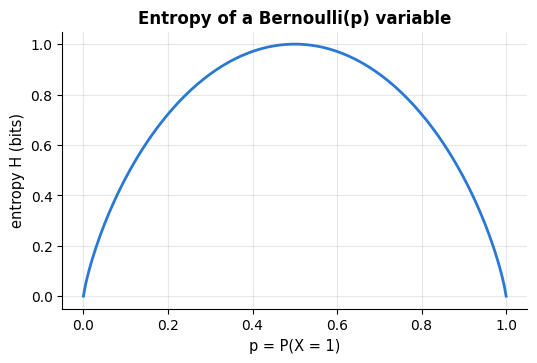

churn label: P(churned = 1) = 0.326 -> H = 0.911 bits (max 1 bit)
contract type {'Month-to-month': 0.559, 'One year': 0.244, 'Two year': 0.197} -> H = 1.427 bits (max log2(3) = 1.585)
uniform over 8 outcomes: H = 3.0 bits; a certain outcome: H = 0.0 bits


In [27]:
def entropy(p, base=2):
    """Entropy -sum p log p of the probability vector p, in bits by default (base=2; base=np.e gives nats)."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0]                                   # 0 log 0 = 0
    # dividing by log(base) converts the natural log into a log to that base
    return float(-np.sum(p * np.log(p)) / np.log(base)) + 0.0     # + 0.0 turns -0.0 into 0.0

ps = np.linspace(0, 1, 201)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(ps, [entropy([p, 1 - p]) for p in ps], lw=2)   # the entropy of the distribution (p, 1 - p) for every p
ax.set_xlabel("p = P(X = 1)")
ax.set_ylabel("entropy H (bits)")
ax.set_title("Entropy of a Bernoulli(p) variable")
plt.show()

churn_rate = churn["churned"].mean()
print(f"churn label: P(churned = 1) = {churn_rate:.3f} -> H = {entropy([churn_rate, 1 - churn_rate]):.3f} bits (max 1 bit)")
p_contract = churn["contract"].value_counts(normalize=True)    # share of customers per contract type
print(f"contract type {p_contract.round(3).to_dict()} -> H = {entropy(p_contract):.3f} bits (max log2(3) = {np.log2(3):.3f})")
print(f"uniform over 8 outcomes: H = {entropy(np.full(8, 1 / 8)):.1f} bits; a certain outcome: H = {entropy([1.0]):.1f} bits")

### 5.2 Cross-entropy and KL divergence

If the true distribution is $p$ but we encode outcomes using a code optimised for $q$
(a model's predicted probabilities, say), the average code length is the **cross-entropy**

$$
H(p, q) = -\sum_x p(x)\log q(x),
$$

and the *excess* over the best possible length is the **Kullback–Leibler divergence**
(Kullback & Leibler, 1951),

$$
D_{\mathrm{KL}}(p \,\|\, q) = \sum_x p(x)\log\frac{p(x)}{q(x)} = H(p, q) - H(p) .
$$

**KL is never negative, and zero only if $p = q$** (Gibbs' inequality). Proof: since
$\ln t \le t - 1$ for all $t > 0$, with equality only at $t = 1$,

$$
-D_{\mathrm{KL}}(p\,\|\,q) = \sum_x p(x)\ln\frac{q(x)}{p(x)} \;\le\; \sum_x p(x)\Big(\frac{q(x)}{p(x)} - 1\Big) = \sum_x q(x) - \sum_x p(x) = 0 .
$$

KL is *not* symmetric — $D_{\mathrm{KL}}(p\|q) \ne D_{\mathrm{KL}}(q\|p)$ in general — so
it is a divergence, not a distance. For two Gaussians it has a closed form,
$D_{\mathrm{KL}}\big(\mathcal{N}(\mu_1, \sigma_1^2)\,\|\,\mathcal{N}(\mu_2, \sigma_2^2)\big)
= \log\frac{\sigma_2}{\sigma_1} + \frac{\sigma_1^2 + (\mu_1 - \mu_2)^2}{2\sigma_2^2} - \frac{1}{2}$,
which we can verify by numerical integration.

H(p) = 1.4855  H(p, q) = 1.8084  KL(p||q) = 0.3229  KL(q||p) = 0.2796 bits
KL(p||p) = 0.0000;  H(p, q) >= H(p): True
smallest KL over 2000 random pairs of distributions: 0.0204  (Gibbs' inequality: never negative)
KL between two Gaussians: closed form 0.34991 nats, numerical integration 0.34991 nats


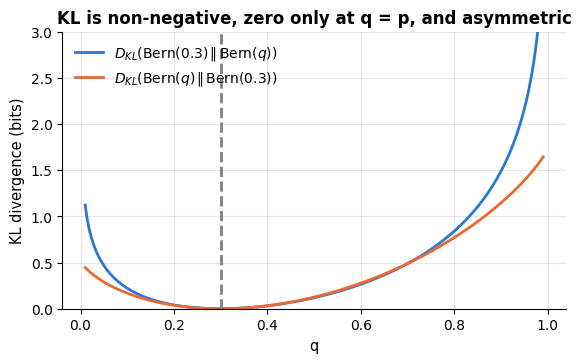

In [28]:
def cross_entropy(p, q, base=2):
    """Cross-entropy H(p, q) = -sum p log q, in bits by default; terms where p = 0 contribute nothing."""
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    mask = p > 0
    return -np.sum(p[mask] * np.log(q[mask])) / np.log(base)

def kl_divergence(p, q, base=2):
    """Kullback-Leibler divergence KL(p || q) = H(p, q) - H(p), in bits by default."""
    return cross_entropy(p, q, base) - entropy(p, base)

p = np.array([0.5, 0.3, 0.2])
q = np.array([0.2, 0.5, 0.3])
print(f"H(p) = {entropy(p):.4f}  H(p, q) = {cross_entropy(p, q):.4f}  KL(p||q) = {kl_divergence(p, q):.4f}  KL(q||p) = {kl_divergence(q, p):.4f} bits")
print(f"KL(p||p) = {kl_divergence(p, p):.4f};  H(p, q) >= H(p): {cross_entropy(p, q) >= entropy(p)}")
# rng.dirichlet(np.ones(5)) draws a random probability vector of length 5 (non-negative, summing to 1);
# size=(2000, 2) gives an array of shape (2000, 2, 5): 2000 pairs of distributions
random_pairs = rng.dirichlet(np.ones(5), size=(2000, 2))
kls = [kl_divergence(a, b) for a, b in random_pairs]   # each item is a (2, 5) array, unpacked into a and b
print(f"smallest KL over 2000 random pairs of distributions: {min(kls):.4f}  (Gibbs' inequality: never negative)")

mu1, s1, mu2, s2 = 0.0, 1.0, 1.0, 1.5
kl_closed = np.log(s2 / s1) + (s1 ** 2 + (mu1 - mu2) ** 2) / (2 * s2 ** 2) - 0.5   # natural log -> nats
# the KL integrand p(x) (log p(x) - log q(x)) for p = N(mu1, s1^2) and q = N(mu2, s2^2)
integrand = lambda x: stats.norm(mu1, s1).pdf(x) * (stats.norm(mu1, s1).logpdf(x) - stats.norm(mu2, s2).logpdf(x))
# integrate.quad(f, a, b) numerically integrates f from a to b and returns (value, error estimate); [0] is the value
kl_numeric = integrate.quad(integrand, -20, 20)[0]
print(f"KL between two Gaussians: closed form {kl_closed:.5f} nats, numerical integration {kl_numeric:.5f} nats")

qs = np.linspace(0.01, 0.99, 300)
p_fixed = 0.3
fig, ax = plt.subplots(figsize=(6.5, 3.6))
# KL in both directions between Bernoulli(0.3) and Bernoulli(q), for every q on the grid
ax.plot(qs, [kl_divergence([p_fixed, 1 - p_fixed], [q_, 1 - q_]) for q_ in qs], lw=2, label="$D_{KL}(\\mathrm{Bern}(0.3)\\,\\|\\,\\mathrm{Bern}(q))$")
ax.plot(qs, [kl_divergence([q_, 1 - q_], [p_fixed, 1 - p_fixed]) for q_ in qs], lw=2, label="$D_{KL}(\\mathrm{Bern}(q)\\,\\|\\,\\mathrm{Bern}(0.3))$")
ax.axvline(p_fixed, color="gray", ls="--")
ax.set_ylim(0, 3)
ax.set_xlabel("q")
ax.set_ylabel("KL divergence (bits)")
ax.set_title("KL is non-negative, zero only at q = p, and asymmetric")
ax.legend()
plt.show()

### 5.3 From information theory to loss functions and decision trees

Three consequences tie this section to the rest of the course.

**Cross-entropy loss is KL minimisation, is maximum likelihood.** Write the empirical
distribution of the labels for input $\mathbf{x}_i$ as $p_i$ (a one-hot vector) and the
model's prediction as $q_i$. The average cross-entropy $\frac{1}{n}\sum_i H(p_i, q_i) =
-\frac{1}{n}\sum_i \log q_i(y_i)$ is exactly the negative log-likelihood of section 4.3;
because $H(p_i)$ is a constant, minimising it minimises $\frac{1}{n}\sum_i
D_{\mathrm{KL}}(p_i \| q_i)$, i.e. it pushes the predicted distribution towards the observed
one. This is why the softmax + cross-entropy combination is the default output layer of
neural network classifiers, and why the log loss (notebook 7) is a proper
score for probabilities.

**Mutual information** measures how much knowing $X$ tells you about $Y$:
$I(X; Y) = D_{\mathrm{KL}}\big(p(x, y)\,\|\,p(x)p(y)\big) = H(Y) - H(Y \mid X)$, where
$H(Y \mid X) = \sum_x p(x) H(Y \mid X = x)$ is the conditional entropy. It is zero exactly
when $X$ and $Y$ are independent, and it is the basis of the `mutual_info_*` feature
selectors in notebook 4.

**Information gain in decision trees.** Splitting a node whose labels have entropy $H(Y)$
on feature $X$ leaves children with average entropy $H(Y \mid X)$; the reduction
$H(Y) - H(Y \mid X)$ is the **information gain** — and it *is* the mutual information
between the feature and the label. Notebook 9 grows trees by picking, at every node, the
split with the largest gain (or the largest decrease of the closely related Gini
impurity). Computed on the churn data, using the joint table from section 3.3:

In [29]:
from sklearn.metrics import mutual_info_score   # mutual information between two columns of discrete labels

H_churn = entropy(marg_churn)                   # H(Y): entropy of the churn label
# H(Y | X) = sum over contracts c of P(c) * H(Y | X = c); conditional.loc[c] is the row (P(0 | c), P(1 | c))
H_churn_given_contract = sum(marg_contract[c] * entropy(conditional.loc[c]) for c in conditional.index)
info_gain = H_churn - H_churn_given_contract
# flatten the 3 x 2 joint table and the independence table into two distributions over 6 outcomes
mi_from_kl = kl_divergence(joint.to_numpy().ravel(), independent.ravel())
mi_sklearn = mutual_info_score(churn["contract"], churn["churned"]) / np.log(2)      # sklearn returns nats

print(f"H(churned) = {H_churn:.4f} bits;  H(churned | contract) = {H_churn_given_contract:.4f} bits")
print(f"information gain of splitting on contract = {info_gain:.4f} bits")
print(f"mutual information as KL(joint || product of marginals) = {mi_from_kl:.4f} bits;  sklearn mutual_info_score = {mi_sklearn:.4f} bits")
for feature in ["internet_service", "payment_method", "region", "senior_citizen"]:
    print(f"  information gain of {feature:17s}: {mutual_info_score(churn[feature], churn['churned']) / np.log(2):.4f} bits")

H(churned) = 0.9112 bits;  H(churned | contract) = 0.8043 bits
information gain of splitting on contract = 0.1069 bits
mutual information as KL(joint || product of marginals) = 0.1069 bits;  sklearn mutual_info_score = 0.1069 bits
  information gain of internet_service : 0.0775 bits
  information gain of payment_method   : 0.0014 bits
  information gain of region           : 0.0008 bits
  information gain of senior_citizen   : 0.0024 bits


Contract type is by far the most informative of these features about churn (a tree would
split on it first), and `region` carries essentially none — consistent with how the data
were generated.

## Summary

- **Linear algebra.** Norms and dot products measure size and similarity; matrices are
  linear maps with a rank and, when square and full-rank, an inverse. Least squares is a
  *projection* onto the column space of $\mathbf{X}$. Symmetric matrices have orthogonal
  eigenvectors; every matrix has an SVD whose truncation is the best low-rank
  approximation. Covariance and Gram matrices are PSD; adding $\lambda\mathbf{I}$ makes
  them PD.
- **Calculus.** The gradient is the direction of steepest ascent; the chain rule composes
  gradients (backpropagation); check every hand-derived gradient numerically. Gradient
  descent converges for $\eta < 2/\lambda_{\max}$ at a speed governed by the condition
  number (scale your features!); on convex functions it finds the global minimum, on
  non-convex ones a local one that depends on the start.
- **Probability.** Expectation is linear, variance adds for independent variables; joint =
  conditional × marginal; Bayes' theorem turns likelihood and prior into a posterior, and
  base rates matter. LLN: averages converge; CLT: averages are Gaussian with standard error
  $\sigma/\sqrt{n}$.
- **Statistics.** MSE = bias² + variance. Least squares = Gaussian MLE, cross-entropy =
  Bernoulli negative log-likelihood, ridge = MAP with a Gaussian prior. Confidence
  intervals via the CLT or, for any statistic, via the bootstrap. Paired $t$-tests on CV
  folds are optimistic.
- **Information theory.** Entropy = expected surprise = impurity; cross-entropy = entropy +
  KL; KL $\ge 0$ and asymmetric; minimising cross-entropy = MLE; information gain = mutual
  information.

| Concept | Formula | Where it is used |
|---|---|---|
| cosine similarity | $\mathbf{x}^\top\mathbf{y} / (\|\mathbf{x}\|\|\mathbf{y}\|)$ | text and embeddings (18, 19) |
| projection / normal equations | $\mathbf{X}^\top\mathbf{X}\mathbf{w} = \mathbf{X}^\top\mathbf{y}$ | linear regression (6) |
| eigen-decomposition of $\boldsymbol{\Sigma}$ | $\boldsymbol{\Sigma} = \mathbf{Q}\boldsymbol{\Lambda}\mathbf{Q}^\top$ | PCA (14), Gaussian mixtures (13) |
| truncated SVD | $\mathbf{A}_k = \sum_{i \le k}\sigma_i\mathbf{u}_i\mathbf{v}_i^\top$ | PCA, LSA, recommenders (14, 19) |
| gradient descent | $\mathbf{w} \leftarrow \mathbf{w} - \eta\nabla\mathcal{L}$, $\eta < 2/\lambda_{\max}$ | everything from 6 to 18 |
| Bayes' theorem | $P(y \mid \mathbf{x}) \propto P(\mathbf{x} \mid y)P(y)$ | naive Bayes (8), calibration (7) |
| CLT / standard error | $\bar{x} \pm 1.96\, s/\sqrt{n}$ | error bars on CV scores (5, 12) |
| MLE | $\arg\max_\theta \sum_i \log p(x_i \mid \theta)$ | least squares (6), logistic regression (7), EM (13) |
| bootstrap | resample with replacement, take quantiles | confidence intervals (6, 24), bagging (10) |
| entropy, information gain | $H = -\sum p\log p$, $H(Y) - H(Y \mid X)$ | decision trees (9), feature selection (4) |
| cross-entropy | $-\sum_x p(x)\log q(x)$ | log loss (7), neural networks (15–17) |

**Next steps:** notebook 3 (exploratory data analysis) applies the descriptive statistics;
notebook 5 (fundamentals) builds the bias–variance decomposition on section 4.1; notebook
6 (linear regression) derives least squares and ridge in full from sections 1.3, 2.2 and
4.4; notebook 7 (logistic regression) develops the cross-entropy loss and its gradient;
notebook 9 (decision trees) uses information gain; notebook 14 (dimensionality reduction)
builds PCA on sections 1.4–1.5.

## Exercises

### Exercise 1 — The projection formula (easy)
Draw a random matrix `A` of shape `(20, 3)` and a random vector `b` of length 20. Compute
the projection matrix $\mathbf{P} = \mathbf{A}(\mathbf{A}^\top\mathbf{A})^{-1}\mathbf{A}^\top$
and verify numerically that (a) $\mathbf{P}^2 = \mathbf{P}$, (b) $\mathbf{P}^\top = \mathbf{P}$,
(c) the eigenvalues of $\mathbf{P}$ are only 0 and 1, with exactly three 1s, (d)
$\|\mathbf{b} - \mathbf{P}\mathbf{b}\| \le \|\mathbf{b} - \mathbf{A}\mathbf{w}\|$ for 1 000
random $\mathbf{w}$. Then compute the SVD of $\mathbf{A}$ and show that
$\mathbf{P} = \mathbf{U}\mathbf{U}^\top$.

<details><summary>Solution sketch</summary>

`P = A @ np.linalg.solve(A.T @ A, A.T)`; `np.linalg.eigvalsh(P).round(6)` shows 17 zeros
and 3 ones (the rank); `U, s, Vt = np.linalg.svd(A, full_matrices=False)` and
`np.allclose(P, U @ U.T)` — projection onto the column space only needs an orthonormal
basis of it, which is what $\mathbf{U}$ provides.
</details>

### Exercise 2 — Newton's method in one dimension (medium)
Newton's method uses curvature as well as slope: $x_{t+1} = x_t - f'(x_t)/f''(x_t)$.
Implement it and gradient descent for $f(x) = x^4 - 3x^2 + x$ from $x_0 = 2$, and compare
the number of iterations each needs to reach $|f'(x)| < 10^{-8}$. Then start both from
$x_0 = -0.2$. What does Newton's method converge to, and why? (Hint: section 2.5.)

<details><summary>Solution sketch</summary>

With $f' = 4x^3 - 6x + 1$ and $f'' = 12x^2 - 6$, Newton converges in about 6 iterations
from $x_0 = 2$ versus hundreds for gradient descent with a safe $\eta$ (quadratic vs. linear
convergence). From $x_0 = -0.2$, $f'' < 0$: Newton steps *uphill* to the local maximum near
$x \approx 0.17$ — it finds stationary points, not minima. Notebook 7 mentions Newton/IRLS
for logistic regression, where convexity guarantees $f'' > 0$.
</details>

### Exercise 3 — Maximum likelihood for a Poisson (medium)
The number of support tickets per customer looks like a count variable. Derive the MLE of
$\lambda$ for i.i.d. Poisson data (log-likelihood $\ell(\lambda) = \sum_i [x_i\log\lambda -
\lambda - \log x_i!]$), then estimate it on `churn["support_tickets"]`, plot the fitted PMF
over the empirical histogram, and compare mean and variance of the data. Is the Poisson
model adequate?

<details><summary>Solution sketch</summary>

$\ell'(\lambda) = \sum_i x_i/\lambda - n = 0 \Rightarrow \hat\lambda = \bar{x}$. On the churn
data the sample variance exceeds the mean (over-dispersion), because $\lambda$ differs
between customers (fibre customers file more tickets) — a mixture of Poissons is not a
Poisson. `stats.poisson(x.mean()).pmf(k)` versus `np.bincount(x) / len(x)` shows the
mismatch in the tail.
</details>

### Exercise 4 — Bootstrap vs. analytic intervals for a correlation (medium)
Take `tenure_months` and `total_charges` from `load_churn()` (drop missing values). Compute
the Pearson correlation and a 95 % bootstrap percentile interval with 2 000 resamples of
*rows* (resample index pairs, not the two columns separately). Compare with Fisher's
$z$-transformation interval: $z = \operatorname{artanh}(r) \pm 1.96/\sqrt{n - 3}$, then
$\tanh$ back. Repeat on a random subsample of 40 customers. When do the two disagree?

<details><summary>Solution sketch</summary>

```py
idx = rng.integers(0, n, size=(2000, n))
boot_r = [np.corrcoef(x[i], y[i])[0, 1] for i in idx]
```
For $n \approx 5000$ both intervals are tiny and agree; for $n = 40$ the sampling
distribution of $r$ is skewed (it is bounded by 1) and the two intervals differ noticeably,
the bootstrap interval being asymmetric.
</details>

### Exercise 5 — Entropy of class distributions and the best split (medium)
Write a function `information_gain(df, feature, target)` that computes
$H(Y) - H(Y \mid X)$ for a categorical feature, and apply it to every categorical column of
`load_churn()`. Then bin `tenure_months` into 2, 4 and 8 equal-frequency buckets
(`pd.qcut`) and compute the gain of each binning. Why does the gain increase with the
number of buckets, and why is that a problem for tree learning? (Notebook 9 discusses the
bias of information gain towards many-valued features.)

<details><summary>Solution sketch</summary>

More buckets can only decrease conditional entropy (a finer partition never increases
$H(Y \mid X)$), so gain is monotone in the number of categories even when the extra
categories carry noise — a customer ID with 5 000 values would have the maximal gain and
zero predictive value. C4.5 corrects for this with the *gain ratio*; CART limits itself
to binary splits.
</details>

### Exercise 6 — Gradient descent with momentum (hard)
Add momentum to `gradient_descent`: keep a velocity $\mathbf{v} \leftarrow \beta\mathbf{v}
- \eta\nabla f(\mathbf{w})$, $\mathbf{w} \leftarrow \mathbf{w} + \mathbf{v}$ (Polyak, 1964).
On the bowl with condition number 25, compare the number of steps needed to reduce the
loss by 1000× for plain gradient descent ($\eta = 0.072$) and momentum ($\eta = 0.04$,
$\beta = 0.8$). Plot both trajectories on the contour plot. Then try $\beta = 0.95$ and
explain what you see.

<details><summary>Solution sketch</summary>

Momentum damps the oscillation along the steep axis and accelerates along the flat one;
it typically needs several times fewer steps on ill-conditioned problems. Too much momentum
($\beta$ close to 1) overshoots and the trajectory spirals around the minimum before
settling. Momentum and adaptive step sizes (RMSProp, Adam) are the standard remedies; scikit-learn exposes the simplest of them through `SGDRegressor(learning_rate="adaptive")`.
</details>

## References and further reading

### Textbooks

- Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*. Cambridge University Press. (free at https://mml-book.github.io) — Written for exactly this purpose: chapters 2–7 cover linear algebra, geometry, matrix decompositions, vector calculus, probability and optimisation; chapters 8–10 apply them to regression, PCA and density estimation.
- Strang, G. (2019). *Linear Algebra and Learning from Data*. Wellesley-Cambridge Press. — Strang's ML-flavoured linear algebra: the SVD, least squares, the four fundamental subspaces, and optimisation for deep learning.
- Boyd, S., & Vandenberghe, L. (2018). *Introduction to Applied Linear Algebra: Vectors, Matrices, and Least Squares*. Cambridge University Press. (free) — Gentle and concrete; chapters 3 (norms, distance, angle) and 12–15 (least squares and regularisation).
- Boyd, S., & Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press. (free) — Chapters 2–4 define convexity; chapter 9 analyses gradient descent and Newton's method, including conditioning.
- Nocedal, J., & Wright, S. J. (2006). *Numerical Optimization* (2nd ed.). Springer. — The standard reference on line search, quasi-Newton methods (BFGS, used by `scipy.optimize.minimize`) and more.
- Wasserman, L. (2004). *All of Statistics: A Concise Course in Statistical Inference*. Springer. — The statistics of this notebook in compact, mathematically honest form; chapter 8 is the bootstrap, chapter 9 maximum likelihood.
- Blitzstein, J. K., & Hwang, J. (2019). *Introduction to Probability* (2nd ed.). CRC Press. (free) — The friendliest rigorous probability book; chapter 2 (conditioning and Bayes), chapter 10 (LLN and CLT).
- MacKay, D. J. C. (2003). *Information Theory, Inference, and Learning Algorithms*. Cambridge University Press. (free) — Chapters 1–2 and 8 for entropy and KL divergence with the coding interpretation.
- Cover, T. M., & Thomas, J. A. (2006). *Elements of Information Theory* (2nd ed.). Wiley. — Chapter 2 is the standard treatment of entropy, relative entropy and mutual information.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. (free) — Chapters 2–8 parallel this notebook in more depth: probability, statistics, decision theory, information theory, linear algebra, optimisation.

### Papers

- Eckart, C., & Young, G. (1936). The approximation of one matrix by another of lower rank. *Psychometrika*, 1(3), 211–218. — The low-rank approximation theorem of section 1.5.
- Cauchy, A.-L. (1847). Méthode générale pour la résolution des systèmes d'équations simultanées. *Comptes Rendus de l'Académie des Sciences*, 25, 536–538. — The origin of gradient descent.
- Robbins, H., & Monro, S. (1951). A stochastic approximation method. *The Annals of Mathematical Statistics*, 22(3), 400–407. — Stochastic gradient descent.
- Bottou, L., Curtis, F. E., & Nocedal, J. (2018). Optimization methods for large-scale machine learning. *SIAM Review*, 60(2), 223–311. — A thorough survey of gradient methods as used in machine learning.
- Polyak, B. T. (1964). Some methods of speeding up the convergence of iteration methods. *USSR Computational Mathematics and Mathematical Physics*, 4(5), 1–17. — Momentum (exercise 6).
- Fisher, R. A. (1922). On the mathematical foundations of theoretical statistics. *Philosophical Transactions of the Royal Society A*, 222, 309–368. — Maximum likelihood, consistency and efficiency.
- Efron, B. (1979). Bootstrap methods: another look at the jackknife. *The Annals of Statistics*, 7(1), 1–26. — The bootstrap.
- Dietterich, T. G. (1998). Approximate statistical tests for comparing supervised classification learning algorithms. *Neural Computation*, 10(7), 1895–1923. — Why $t$-tests on CV folds are optimistic; the $5 \times 2$ CV test.
- Nadeau, C., & Bengio, Y. (2003). Inference for the generalization error. *Machine Learning*, 52(3), 239–281. — A variance correction for repeated cross-validation.
- Shannon, C. E. (1948). A mathematical theory of communication. *Bell System Technical Journal*, 27(3), 379–423. — Entropy, and the birth of information theory.
- Kullback, S., & Leibler, R. A. (1951). On information and sufficiency. *The Annals of Mathematical Statistics*, 22(1), 79–86. — The KL divergence.

### Documentation and online resources (free)

- NumPy reference, *Linear algebra (`numpy.linalg`)* — https://numpy.org/doc/stable/reference/routines.linalg.html
- SciPy user guide, *Statistics* and *Optimization* — https://docs.scipy.org/doc/scipy/tutorial/stats.html and https://docs.scipy.org/doc/scipy/tutorial/optimize.html
- 3Blue1Brown, *Essence of linear algebra* and *Essence of calculus* (video series) — https://www.3blue1brown.com — The geometric intuition for sections 1 and 2, animated.